<a href="https://colab.research.google.com/github/donna6355/study_python/blob/master/dl/TensorFlow_Keras_%E1%84%89%E1%85%B5%E1%86%AF%E1%84%89%E1%85%B3%E1%86%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TensorFlow & Keras 실습

> **Google이 만든 대표 딥러닝 프레임워크 TensorFlow를**
> **고수준 API인 Keras로 직접 실습합니다. 빈칸을 채우면서 자연스럽게 배워요!**

---

## 학습 목표

이 노트북을 끝까지 따라오면 다음을 할 수 있게 됩니다.

1. **텐서, Variable, GradientTape** 로 자동 미분과 학습 루프 구현하기
2. **Keras Sequential API** 로 빠르게 모델 만들기
3. **Keras Functional API** 로 복잡한 구조 설계하기
4. **`model.compile() / fit()`** 으로 학습을 한 줄에 끝내기
5. **CNN으로 이미지 분류** (Fashion MNIST)
6. **콜백, 모델 저장, 데이터 증강** 활용
7. **MobileNetV2 전이학습** 으로 적은 데이터에서 좋은 성능 내기

## 진행 순서

| 단계 | 주제 |
|---|---|
| 1 | 환경 준비 + GPU 확인 |
| 2 | TensorFlow와 Keras 이해하기 |
| 3 | [실습 1] 텐서와 Variable 다루기 |
| 4 | [실습 2] GradientTape로 학습 루프 |
| 5 | Sequential API - Keras 매직 |
| 6 | [실습 3] 회귀 모델 빠르게 만들기 |
| 7 | Functional API - 복잡한 구조 설계 |
| 8 | [실습 4] CNN으로 옷 분류 (Fashion MNIST) |
| 9 | 콜백 + 모델 저장 |
| 10 | 데이터 증강 (Data Augmentation) |
| 11 | [실습 5] 전이학습 - CIFAR-10 + MobileNetV2 |
| 12 | 정리 |

## 사전 준비

- **Google Colab** 권장 (무료 GPU 사용 가능)
- 메뉴: 런타임 -> 런타임 유형 변경 -> T4 GPU 선택
- 처음 데이터/모델 다운로드 시 약 5분 소요

## 실습 코드 사용법

이 노트북에는 **5개의 빈칸 채우기 연습**이 있습니다.

- **연습 셀**: 빈칸(`...`)을 채워서 함수를 완성합니다
- **자가 검증 셀**: 실행하면 정답인지 자동으로 알려줍니다
- **정답 보기**: 충분히 시도해본 뒤 펼쳐보세요

## 1. 환경 준비

In [3]:
# 한글 폰트 설치 (코랩 1회만)
!apt-get -qq install -y fonts-nanum > /dev/null
!fc-cache -fv > /dev/null

# TensorFlow의 시끄러운 로그 끄기
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fe = fm.FontEntry(fname=font_path, name='NanumGothic')
fm.fontManager.ttflist.insert(0, fe)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import random

# 재현성을 위한 시드 고정
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(42)

print(f"TensorFlow 버전: {tf.__version__}")
print(f"Keras 버전:      {keras.__version__}")

# GPU 확인
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU 사용 가능:   {gpus[0].name}")
    # GPU 메모리 동적 할당 (코랩 GPU 안정성을 위해)
    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except:
            pass
else:
    print("GPU 없음 (CPU로 실행)")

print("\n환경 준비 완료!")

TensorFlow 버전: 2.20.0
Keras 버전:      3.13.2
GPU 사용 가능:   /physical_device:GPU:0

환경 준비 완료!


## 2. TensorFlow & Keras가 뭔가요?

### 한 줄 요약

> **TensorFlow = 딥러닝 엔진 (Google)**
> **Keras = TensorFlow를 쉽게 쓰는 고수준 API**

자동차로 비유하면:
- **TensorFlow** = 엔진과 변속기 (강력하지만 다루기 어려움)
- **Keras** = 운전대와 페달 (누구나 쉽게 운전 가능)

### TensorFlow가 해주는 일

| 도구 | 역할 |
|---|---|
| **Tensor** | 다차원 배열 (NumPy + GPU 가능) |
| **Variable** | 학습되는 가중치 |
| **GradientTape** | 자동 미분 (PyTorch의 autograd와 같은 일) |
| **Keras Layers** | 모델 부품 (블록처럼 조립) |

### TF 1.x vs TF 2.x (잠깐의 역사)

옛날 TF 1.x는 "그래프를 먼저 그리고 나중에 실행" 하는 방식이라 어려웠습니다.
**TF 2.x (2019~)** 부터는 PyTorch처럼 **실행하면서 동시에 결과 확인** 가능 (Eager Execution)!

### TensorFlow vs PyTorch

| 항목 | PyTorch | TensorFlow / Keras |
|---|---|---|
| 모델 정의 | `class(nn.Module)` | `Sequential` 또는 `Functional` |
| 학습 루프 | for문 직접 작성 | `model.fit()` 한 줄 |
| 채널 위치 | `(N, C, H, W)` | `(N, H, W, C)` |
| 주류 분야 | 연구, LLM | 모바일, 산업 배포 |

> **둘 다 잘합니다. 다만 코드 스타일이 다르므로 둘 다 읽을 줄 알면 좋아요.**

### 어디서 자주 쓰나?

- **TensorFlow Lite (TFLite)**: 모바일/임베디드 배포 최강
- **TensorFlow Serving**: 대규모 서비스 배포
- **Google 클라우드 / Vertex AI**: 통합 좋음
- **Edge TPU**: 구글 전용 가속기

## 3. 텐서(Tensor) - 데이터의 기본 단위

PyTorch와 거의 똑같이 다차원 배열입니다.

| 차원 | 이름 | 예시 |
|---|---|---|
| 0차원 | 스칼라 | 7 |
| 1차원 | 벡터 | [1, 2, 3] |
| 2차원 | 행렬 | [[1,2],[3,4]] |
| 3차원 | 컬러 사진 1장 | (H, W, C) |
| 4차원 | 사진 묶음 | (N, H, W, C) |

### TensorFlow의 두 가지 텐서

| 종류 | 설명 | 예시 |
|---|---|---|
| **`tf.constant`** | 변하지 않는 데이터 (입력, 정답) | 학습 데이터 |
| **`tf.Variable`** | 학습되며 변하는 데이터 (가중치) | 모델 파라미터 |

> **Variable이 핵심**: 학습 시 값이 바뀌어야 하는 것은 모두 Variable로!

In [4]:
# 다양한 텐서 만들기
print("=== 0~3차원 텐서 ===")

scalar = tf.constant(7)
print(f"스칼라: {scalar}, 차원: {scalar.ndim}")

vector = tf.constant([1.0, 2.0, 3.0])
print(f"벡터:   {vector.numpy()}, 차원: {vector.ndim}")

matrix = tf.constant([[1, 2], [3, 4]])
print(f"행렬:\n{matrix.numpy()}\nshape: {matrix.shape}")

tensor3d = tf.zeros([2, 3, 4])
print(f"\n3D 텐서 shape: {tensor3d.shape}")

print("\n=== 자주 쓰는 생성 함수 ===")
print(f"영행렬 zeros(2,3):\n{tf.zeros([2, 3]).numpy()}")
print(f"\n일행렬 ones(2,3):\n{tf.ones([2, 3]).numpy()}")
print(f"\n랜덤 normal(2,3):\n{tf.random.normal([2, 3]).numpy()}")
print(f"\n구간 range(0,10,2):\n{tf.range(0, 10, 2).numpy()}")

=== 0~3차원 텐서 ===
스칼라: 7, 차원: 0
벡터:   [1. 2. 3.], 차원: 1
행렬:
[[1 2]
 [3 4]]
shape: (2, 2)

3D 텐서 shape: (2, 3, 4)

=== 자주 쓰는 생성 함수 ===
영행렬 zeros(2,3):
[[0. 0. 0.]
 [0. 0. 0.]]

일행렬 ones(2,3):
[[1. 1. 1.]
 [1. 1. 1.]]

랜덤 normal(2,3):
[[ 0.3274685 -0.8426258  0.3194337]
 [-1.4075519 -2.3880599 -1.0392479]]

구간 range(0,10,2):
[0 2 4 6 8]


In [5]:
# 텐서 연산 - NumPy와 거의 똑같습니다!
a = tf.constant([[1.0, 2.0], [3.0, 4.0]])
b = tf.constant([[5.0, 6.0], [7.0, 8.0]])

print(f"a + b (덧셈):\n{(a + b).numpy()}")
print(f"\na * b (원소별 곱):\n{(a * b).numpy()}")
print(f"\na @ b (행렬 곱):\n{(a @ b).numpy()}")
print(f"\na 전치:\n{tf.transpose(a).numpy()}")
print(f"\n합계: {tf.reduce_sum(a).numpy()}, 평균: {tf.reduce_mean(a).numpy():.2f}")

# Variable - 학습되는 가중치
print("\n=== Variable - 학습 가능한 텐서 ===")
w = tf.Variable([1.0, 2.0, 3.0], name='weights')
print(f"초기값: {w.numpy()}")

# 값 바꾸기는 assign으로 (= 는 새 텐서를 만들 뿐!)
w.assign([10.0, 20.0, 30.0])
print(f"assign 후: {w.numpy()}")

w.assign_add([1.0, 1.0, 1.0])
print(f"assign_add 후: {w.numpy()}")

w.assign_sub([0.5, 0.5, 0.5])
print(f"assign_sub 후: {w.numpy()}")

a + b (덧셈):
[[ 6.  8.]
 [10. 12.]]

a * b (원소별 곱):
[[ 5. 12.]
 [21. 32.]]

a @ b (행렬 곱):
[[19. 22.]
 [43. 50.]]

a 전치:
[[1. 3.]
 [2. 4.]]

합계: 10.0, 평균: 2.50

=== Variable - 학습 가능한 텐서 ===
초기값: [1. 2. 3.]
assign 후: [10. 20. 30.]
assign_add 후: [11. 21. 31.]
assign_sub 후: [10.5 20.5 30.5]


---

## 실습 1: NumPy 배열을 텐서로 변환하기

NumPy 배열을 TensorFlow 텐서로 바꾸는 함수를 만들어 봅시다.

### 만들어야 할 함수
```python
numpy_to_tf_2d(np_array)
# 입력: 1차원 numpy 배열 (예: [1, 2, 3, 4, 5, 6])
# 출력: 2행짜리 tf 텐서
```

### 힌트 - 2단계!

1. **NumPy -> tf 텐서 변환**:
   - `tf.constant(np_array)` 또는 `tf.convert_to_tensor(np_array)`

2. **shape 변경**:
   - `tf.reshape(tensor, [2, -1])`
   - PyTorch와 비슷하지만 함수 이름이 `tf.reshape`!

### tf.reshape의 -1 마법

`tf.reshape(tensor, [2, -1])` = "2행짜리로 만들고 열은 알아서 계산"
- 6개 원소 -> 2행 3열
- 8개 원소 -> 2행 4열

In [6]:
# 빈칸을 채워서 변환 함수를 완성하세요!
def numpy_to_tf_2d(np_array):
    # TODO 1: numpy 배열을 tf 텐서로 변환
    tensor = tf.convert_to_tensor(np_array)

    # TODO 2: 2행짜리로 reshape
    return tf.reshape(tensor, [2, -1])

In [7]:
# 자가 검증
try:
    # 검증 1) 6개 원소 -> 2x3 행렬
    arr1 = np.array([1, 2, 3, 4, 5, 6])
    result1 = numpy_to_tf_2d(arr1)

    # 검증 2) 10개 원소 -> 2x5 행렬
    arr2 = np.arange(10)
    result2 = numpy_to_tf_2d(arr2)

    is_tensor = isinstance(result1, tf.Tensor)
    shape1_ok = tuple(result1.shape) == (2, 3)
    shape2_ok = tuple(result2.shape) == (2, 5)
    val_ok = np.array_equal(result1.numpy(), [[1, 2, 3], [4, 5, 6]])

    if is_tensor and shape1_ok and shape2_ok and val_ok:
        print(f"정답입니다!")
        print(f"   입력 [1, 2, 3, 4, 5, 6] (1D)")
        print(f"   출력 shape: {tuple(result1.shape)}")
        print(f"   결과:\n{result1.numpy()}")
        print(f"\n   10개 원소 입력 -> shape {tuple(result2.shape)}: 통과")
    else:
        print(f"다시 시도해보세요.")
        print(f"   tf.Tensor 타입: {is_tensor}")
        print(f"   shape (2,3) 기대 -> {tuple(result1.shape)}")
except Exception as e:
    print(f"에러: {e}")
    print("   -> 빈칸을 채웠는지 확인하세요.")

정답입니다!
   입력 [1, 2, 3, 4, 5, 6] (1D)
   출력 shape: (2, 3)
   결과:
[[1 2 3]
 [4 5 6]]

   10개 원소 입력 -> shape (2, 5): 통과


<details>
<summary>정답 보기 (클릭)</summary>

```python
def numpy_to_tf_2d(np_array):
    tensor = tf.constant(np_array)
    return tf.reshape(tensor, [2, -1])
```

또는 한 줄로:

```python
def numpy_to_tf_2d(np_array):
    return tf.reshape(tf.constant(np_array), [2, -1])
```

**해설 - PyTorch와 비교**:

| 작업 | PyTorch | TensorFlow |
|---|---|---|
| numpy -> tensor | `torch.from_numpy(arr)` | `tf.constant(arr)` |
| reshape | `tensor.reshape(2, -1)` | `tf.reshape(tensor, [2, -1])` |
| -1 의미 | "나머지는 알아서" | 똑같음 |

함수 이름과 인자 형식만 다를 뿐, 거의 같은 일을 합니다!

</details>

In [8]:
# 표준 정답 함수
def numpy_to_tf_2d(np_array):
    return tf.reshape(tf.constant(np_array), [2, -1])

print("numpy_to_tf_2d 준비 완료!")

numpy_to_tf_2d 준비 완료!


### 실습 1 보강: 텐서 시각화와 변환

다양한 입력에서 텐서가 어떻게 변환되는지, tf.constant vs tf.Variable의 차이는 무엇인지 봅시다.

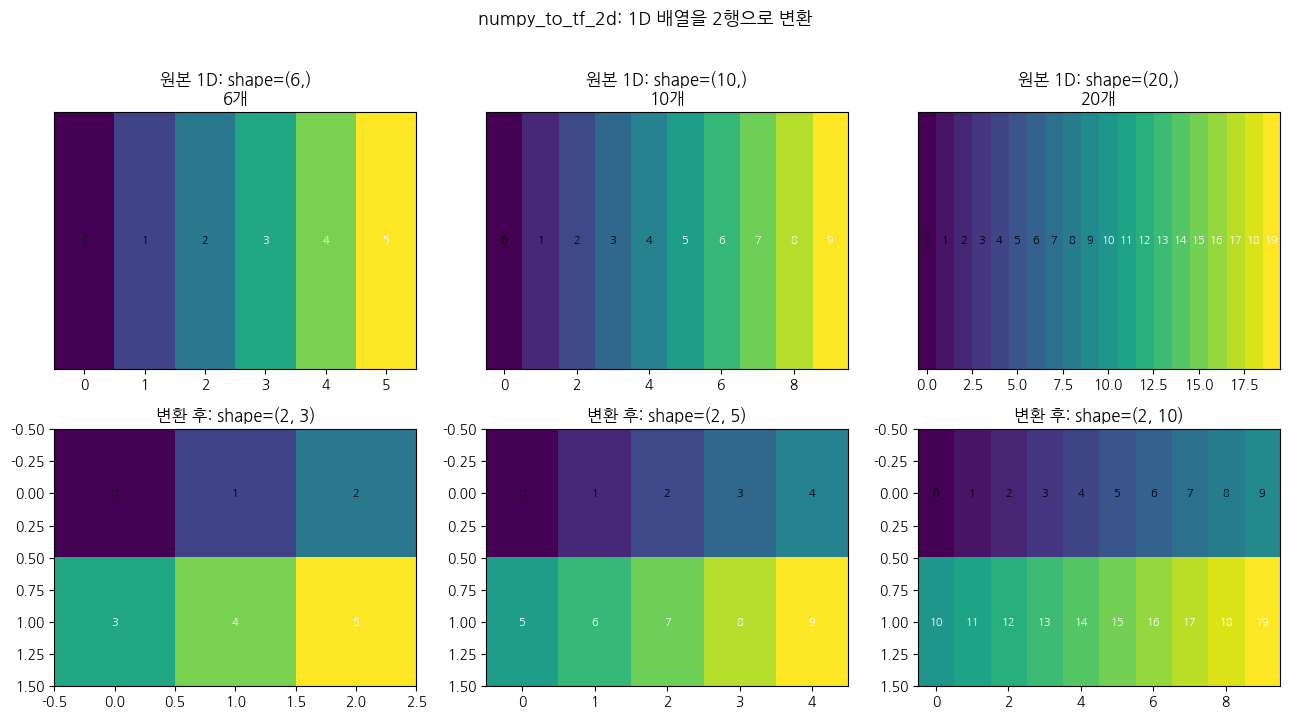

시각화 해석:
- 색이 진할수록 큰 값
- 1D 배열이 그대로 2행으로 잘려서 배치됨
- tf.reshape(tensor, [2, -1]) - PyTorch와 동일한 패턴!


In [9]:
# 시각화 1: 다양한 shape의 텐서 비교
fig, axes = plt.subplots(2, 3, figsize=(13, 7))

test_arrays = [
    ('6개 -> (2, 3)', np.arange(6)),
    ('10개 -> (2, 5)', np.arange(10)),
    ('20개 -> (2, 10)', np.arange(20)),
]

for col, (title, arr) in enumerate(test_arrays):
    # 첫 행: 원본 1D
    axes[0, col].imshow(arr.reshape(1, -1), cmap='viridis', aspect='auto')
    axes[0, col].set_title(f'원본 1D: shape={arr.shape}\n{title.split("->")[0].strip()}')
    axes[0, col].set_yticks([])
    for j, val in enumerate(arr):
        axes[0, col].text(j, 0, str(val), ha='center', va='center',
                            color='white' if val > arr.max()/2 else 'black', fontsize=8)

    # 둘째 행: 변환된 2D 텐서
    result = numpy_to_tf_2d(arr).numpy()
    axes[1, col].imshow(result, cmap='viridis', aspect='auto')
    axes[1, col].set_title(f'변환 후: shape={tuple(result.shape)}')
    for i in range(result.shape[0]):
        for j in range(result.shape[1]):
            val = result[i, j]
            axes[1, col].text(j, i, str(val), ha='center', va='center',
                                color='white' if val > result.max()/2 else 'black', fontsize=8)

plt.suptitle('numpy_to_tf_2d: 1D 배열을 2행으로 변환', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

print("시각화 해석:")
print("- 색이 진할수록 큰 값")
print("- 1D 배열이 그대로 2행으로 잘려서 배치됨")
print("- tf.reshape(tensor, [2, -1]) - PyTorch와 동일한 패턴!")

=== tf.constant vs tf.Variable - 차이점 데모 ===

1) tf.constant: 변경 불가능한 데이터 (입력, 정답)
   값: [1. 2. 3.]
   타입: EagerTensor
   assign 시도 -> 에러: AttributeError (assign 메서드 없음)

2) tf.Variable: 학습 중 변경되는 가중치
   초기값: [1. 2. 3.]
   타입:   ResourceVariable
   assign 후: [10. 20. 30.]
   assign_add 후: [11. 21. 31.]


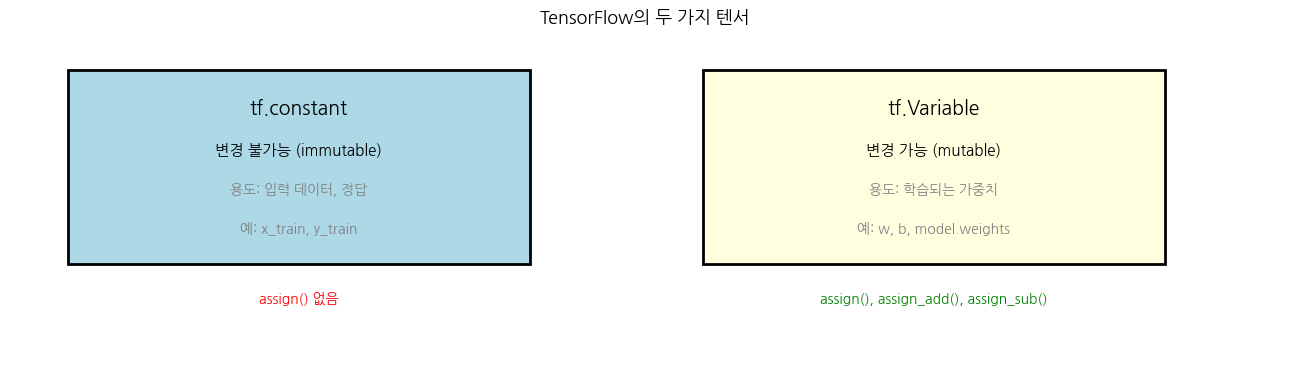


실무 팁:
- 학습 시 변하는 값(가중치) -> tf.Variable
- 학습 시 변하지 않는 값(데이터) -> tf.constant
- Keras의 Dense 등은 내부에서 자동으로 tf.Variable을 만듭니다


In [10]:
# 시각화 2: tf.constant vs tf.Variable - 결정적 차이
print("=== tf.constant vs tf.Variable - 차이점 데모 ===\n")

# 1) tf.constant - 변경 불가 (immutable)
const_tensor = tf.constant([1.0, 2.0, 3.0])
print("1) tf.constant: 변경 불가능한 데이터 (입력, 정답)")
print(f"   값: {const_tensor.numpy()}")
print(f"   타입: {type(const_tensor).__name__}")
try:
    const_tensor.assign([10.0, 20.0, 30.0])   # 시도하면 에러
except AttributeError as e:
    print(f"   assign 시도 -> 에러: AttributeError (assign 메서드 없음)")

# 2) tf.Variable - 변경 가능 (mutable)
var_tensor = tf.Variable([1.0, 2.0, 3.0])
print("\n2) tf.Variable: 학습 중 변경되는 가중치")
print(f"   초기값: {var_tensor.numpy()}")
print(f"   타입:   {type(var_tensor).__name__}")
var_tensor.assign([10.0, 20.0, 30.0])
print(f"   assign 후: {var_tensor.numpy()}")
var_tensor.assign_add([1.0, 1.0, 1.0])
print(f"   assign_add 후: {var_tensor.numpy()}")

# 시각화: 개념도
fig, ax = plt.subplots(figsize=(13, 4))

# tf.constant 박스
ax.add_patch(plt.Rectangle((0.5, 1.0), 4.0, 2.5, facecolor='lightblue',
                              edgecolor='black', linewidth=2))
ax.text(2.5, 3.0, 'tf.constant', ha='center', va='center', fontsize=14, fontweight='bold')
ax.text(2.5, 2.4, '변경 불가능 (immutable)', ha='center', fontsize=11)
ax.text(2.5, 1.9, '용도: 입력 데이터, 정답', ha='center', fontsize=10, color='gray')
ax.text(2.5, 1.4, '예: x_train, y_train', ha='center', fontsize=10, color='gray', style='italic')

# tf.Variable 박스
ax.add_patch(plt.Rectangle((6.0, 1.0), 4.0, 2.5, facecolor='lightyellow',
                              edgecolor='black', linewidth=2))
ax.text(8.0, 3.0, 'tf.Variable', ha='center', va='center', fontsize=14, fontweight='bold')
ax.text(8.0, 2.4, '변경 가능 (mutable)', ha='center', fontsize=11)
ax.text(8.0, 1.9, '용도: 학습되는 가중치', ha='center', fontsize=10, color='gray')
ax.text(8.0, 1.4, '예: w, b, model.weights', ha='center', fontsize=10, color='gray', style='italic')

# 메서드 비교
ax.text(2.5, 0.5, 'assign() 없음', ha='center', fontsize=10, color='red')
ax.text(8.0, 0.5, 'assign(), assign_add(), assign_sub()', ha='center', fontsize=10, color='green')

ax.set_xlim(0, 11); ax.set_ylim(-0.5, 4); ax.axis('off')
ax.set_title('TensorFlow의 두 가지 텐서', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print("\n실무 팁:")
print("- 학습 시 변하는 값(가중치) -> tf.Variable")
print("- 학습 시 변하지 않는 값(데이터) -> tf.constant")
print("- Keras의 Dense 등은 내부에서 자동으로 tf.Variable을 만듭니다")

### 실습 1 추가 테스트: 다양한 케이스

여러 종류의 입력에 대해 함수가 잘 동작하는지 확인합니다.

In [11]:
# 추가 테스트: 5가지 케이스
print("=== 실습 1 종합 테스트 ===\n")
tests_passed = 0

# 테스트 1: 다양한 길이
test1 = True
for n in [4, 6, 8, 10, 100]:
    arr = np.arange(n)
    try:
        result = numpy_to_tf_2d(arr)
        if tuple(result.shape) != (2, n // 2):
            test1 = False; break
    except:
        test1 = False; break
print(f"[테스트 1] 다양한 길이 (4, 6, 8, 10, 100): {'OK' if test1 else 'FAIL'}")
tests_passed += int(test1)

# 테스트 2: 다양한 dtype
test2 = True
for dtype in [np.int32, np.int64, np.float32, np.float64]:
    arr = np.array([1, 2, 3, 4], dtype=dtype)
    try:
        result = numpy_to_tf_2d(arr)
        if not isinstance(result, tf.Tensor):
            test2 = False; break
    except:
        test2 = False; break
print(f"[테스트 2] 다양한 dtype (int32/64, float32/64): {'OK' if test2 else 'FAIL'}")
tests_passed += int(test2)

# 테스트 3: 값 보존
arr = np.array([10, 20, 30, 40, 50, 60])
result = numpy_to_tf_2d(arr)
test3 = np.array_equal(result.numpy(), [[10, 20, 30], [40, 50, 60]])
print(f"[테스트 3] 값 보존: {'OK' if test3 else 'FAIL'}")
tests_passed += int(test3)

# 테스트 4: 2행으로 정확히 분할
test4 = True
for n in [6, 8, 10, 20]:
    arr = np.arange(n)
    result = numpy_to_tf_2d(arr).numpy()
    expected_row0 = list(range(n // 2))
    expected_row1 = list(range(n // 2, n))
    if (list(result[0]) != expected_row0) or (list(result[1]) != expected_row1):
        test4 = False; break
print(f"[테스트 4] 2행으로 순차 분할: {'OK' if test4 else 'FAIL'}")
tests_passed += int(test4)

# 테스트 5: tf.Tensor 인스턴스인가?
arr = np.arange(6)
result = numpy_to_tf_2d(arr)
test5 = isinstance(result, tf.Tensor)
print(f"[테스트 5] 결과가 tf.Tensor: {'OK' if test5 else 'FAIL'} (실제 타입: {type(result).__name__})")
tests_passed += int(test5)

print(f"\n전체: {tests_passed}/5 통과")
if tests_passed == 5:
    print("모든 테스트 통과! 텐서 변환 함수가 견고합니다.")

=== 실습 1 종합 테스트 ===

[테스트 1] 다양한 길이 (4, 6, 8, 10, 100): OK
[테스트 2] 다양한 dtype (int32/64, float32/64): OK
[테스트 3] 값 보존: OK
[테스트 4] 2행으로 순차 분할: OK
[테스트 5] 결과가 tf.Tensor: OK (실제 타입: EagerTensor)

전체: 5/5 통과
모든 테스트 통과! 텐서 변환 함수가 견고합니다.


## 4. 자동 미분 - GradientTape

### GradientTape이란?

> **GradientTape = 학습할 변수들의 모든 연산을 "녹화" 했다가 미분을 계산해주는 도구**

PyTorch의 `loss.backward()` 와 같은 일을 하지만, **명시적으로 녹화 영역을 지정**합니다.

### PyTorch vs TensorFlow 자동 미분

#### PyTorch
```python
x = torch.tensor(3.0, requires_grad=True)
y = x ** 2
y.backward()                # 자동으로 모든 연산 추적됨
print(x.grad)
```

#### TensorFlow (GradientTape)
```python
x = tf.Variable(3.0)
with tf.GradientTape() as tape:    # 이 안의 연산만 녹화
    y = x ** 2
dy_dx = tape.gradient(y, x)
print(dy_dx.numpy())
```

### 차이점 요약

| | PyTorch | TensorFlow |
|---|---|---|
| 미분 대상 표시 | `requires_grad=True` | `tf.Variable` (자동) |
| 추적 범위 | 모든 연산 | `with tf.GradientTape():` 안만 |
| 미분 호출 | `loss.backward()` | `tape.gradient(loss, vars)` |
| 결과 위치 | `x.grad` | 반환값 |

In [12]:
# 단순 예제: y = x², dy/dx = 2x
x = tf.Variable(3.0)

# GradientTape 안에서 일어난 모든 일을 녹화
with tf.GradientTape() as tape:
    y = x ** 2

# y에 대한 x의 미분 계산
dy_dx = tape.gradient(y, x)

print(f"x = {x.numpy()}")
print(f"y = x² = {y.numpy()}")
print(f"dy/dx = 2x = {dy_dx.numpy()} (이론값: 6)")
print(f"\n수학으로 손으로 계산한 답과 정확히 같습니다!")

x = 3.0
y = x² = 9.0
dy/dx = 2x = 6.0 (이론값: 6)

수학으로 손으로 계산한 답과 정확히 같습니다!


---

## 실습 2: GradientTape로 학습 루프 짜기

PyTorch 학습 루프와 같은 5단계 패턴을 TF 스타일로 짜봅시다.

`y = 2x + 1` 데이터를 만들고, 모델이 **w=2, b=1** 을 찾아내도록 학습시킵니다.

### TensorFlow 학습 루프 5단계

| # | 단계 | PyTorch | TensorFlow |
|---|---|---|---|
| 1 | 그래디언트 초기화 | `optimizer.zero_grad()` | (자동, 따로 안 함) |
| 2 | forward | `pred = model(x)` | `with tf.GradientTape():` 안에서 |
| 3 | 손실 계산 | `loss = ...` | (Tape 안에서) |
| 4 | 역전파 | `loss.backward()` | `tape.gradient(loss, vars)` |
| 5 | 가중치 업데이트 | `optimizer.step()` | `var.assign_sub(lr * grad)` |

### 힌트

```python
with tf.GradientTape() as tape:
    y_pred = w * x_data + b
    loss = tf.reduce_mean((y_pred - y_data) ** 2)   # MSE

dw, db = tape.gradient(loss, [w, b])
w.assign_sub(lr * dw)
b.assign_sub(lr * db)
```

### `tf.reduce_mean` 이 뭐야?

NumPy의 `.mean()` 과 같은 일. 이름이 다른 이유는:
- TF는 axis가 여러 개인 경우 **차원을 줄이는(reduce) 연산** 임을 강조하는 명명 규칙
- `tf.reduce_sum`, `tf.reduce_mean`, `tf.reduce_max` 모두 같은 패턴

In [13]:
# 빈칸을 채워서 학습 루프를 완성하세요!

# 데이터 만들기 (정답: y = 2x + 1 + 노이즈)
set_seed(42)
N = 100
x_data = np.linspace(-3, 3, N).astype(np.float32)
y_data = 2.0 * x_data + 1.0 + np.random.normal(0, 0.5, N).astype(np.float32)

# 학습할 변수 (처음엔 모름)
w = tf.Variable(0.0)
b = tf.Variable(0.0)
lr = 0.05

losses = []
for epoch in range(50):
    # TODO 1: GradientTape으로 연산 녹화 시작
    with tf.GradientTape() as tape:

        # TODO 2: 순전파 - 예측값 계산
        y_pred = w * x_data + b

        # TODO 3: 손실 계산 (MSE)
        loss = tf.reduce_mean((y_pred - y_data) ** 2)

    # TODO 4: 역전파 - w, b의 미분 계산
    dw, db = tape.gradient(loss, [w, b])

    # TODO 5: 가중치 업데이트 (assign_sub 사용!)
    w.assign_sub(lr * dw)
    b.assign_sub(lr * db)

    losses.append(loss.numpy())

print(f"학습 결과:")
print(f"   w = {w.numpy():.3f}  (정답: 2.0)")
print(f"   b = {b.numpy():.3f}  (정답: 1.0)")
print(f"   최종 손실: {losses[-1]:.4f}")

학습 결과:
   w = 2.011  (정답: 2.0)
   b = 0.943  (정답: 1.0)
   최종 손실: 0.2038


정답입니다!
   w = 2.011  (정답에 가까움!)
   b = 0.943  (정답에 가까움!)
   초기 손실: 13.4861
   최종 손실: 0.2038

   GradientTape 5단계 정복!


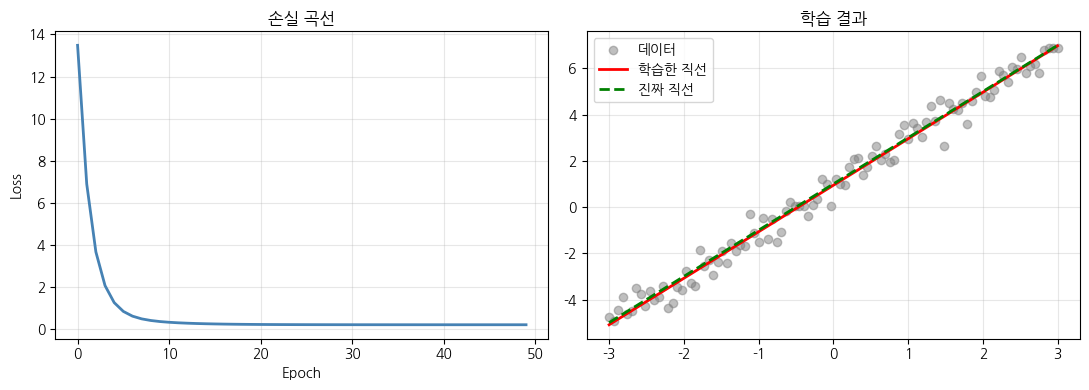

In [14]:
# 자가 검증
try:
    w_ok = abs(w.numpy() - 2.0) < 0.3
    b_ok = abs(b.numpy() - 1.0) < 0.3
    loss_ok = losses[-1] < 1.0
    decreasing = losses[-1] < losses[0]

    if w_ok and b_ok and loss_ok and decreasing:
        print(f"정답입니다!")
        print(f"   w = {w.numpy():.3f}  (정답에 가까움!)")
        print(f"   b = {b.numpy():.3f}  (정답에 가까움!)")
        print(f"   초기 손실: {losses[0]:.4f}")
        print(f"   최종 손실: {losses[-1]:.4f}")
        print(f"\n   GradientTape 5단계 정복!")

        # 시각화
        fig, axes = plt.subplots(1, 2, figsize=(11, 4))
        axes[0].plot(losses, color='steelblue', linewidth=2)
        axes[0].set_title('손실 곡선'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
        axes[0].grid(alpha=0.3)

        axes[1].scatter(x_data, y_data, alpha=0.5, label='데이터', color='gray')
        axes[1].plot(x_data, w * x_data + b, 'r-', label='학습한 직선', linewidth=2)
        axes[1].plot(x_data, 2 * x_data + 1, 'g--', label='진짜 직선', linewidth=2)
        axes[1].set_title('학습 결과')
        axes[1].legend(); axes[1].grid(alpha=0.3)
        plt.tight_layout(); plt.show()
    else:
        print(f"다시 시도해보세요.")
        print(f"   w = {w.numpy()} (기대: 2 근처)")
        print(f"   b = {b.numpy()} (기대: 1 근처)")
except Exception as e:
    print(f"에러: {e}")
    print("   -> 빈칸을 모두 채웠는지 확인하세요.")

<details>
<summary>정답 보기 (클릭)</summary>

```python
with tf.GradientTape() as tape:
    y_pred = w * x_data + b
    loss = tf.reduce_mean((y_pred - y_data) ** 2)

dw, db = tape.gradient(loss, [w, b])
w.assign_sub(lr * dw)
b.assign_sub(lr * db)
```

**해설 - 핵심 포인트**:

1. **`with tf.GradientTape() as tape:`**: 이 안의 연산만 미분 추적
2. **`tape.gradient(loss, [w, b])`**: loss에 대한 [w, b]의 미분을 한 번에!
3. **`var.assign_sub(x)`**: `var = var - x` 와 같지만, **Variable의 값을 in-place로** 바꿈

> 주의: `w = w - lr * dw` 는 **새 텐서를 만들 뿐** Variable의 값을 안 바꿉니다!
> 반드시 `w.assign_sub(lr * dw)` 또는 `w.assign(w - lr * dw)` 로!

### 다음 단계

위 5단계를 직접 짜는 것도 좋지만, Keras에서는 `model.compile() / fit()` 한 줄로 끝낼 수 있어요.
다음 절에서 봅니다!

</details>

### 실습 2 보강: GradientTape 학습 과정 시각화

학습이 진행되며 w와 b가 어떻게 정답을 향해 움직이는지, 손실은 어떻게 줄어드는지 시각적으로 봅시다.

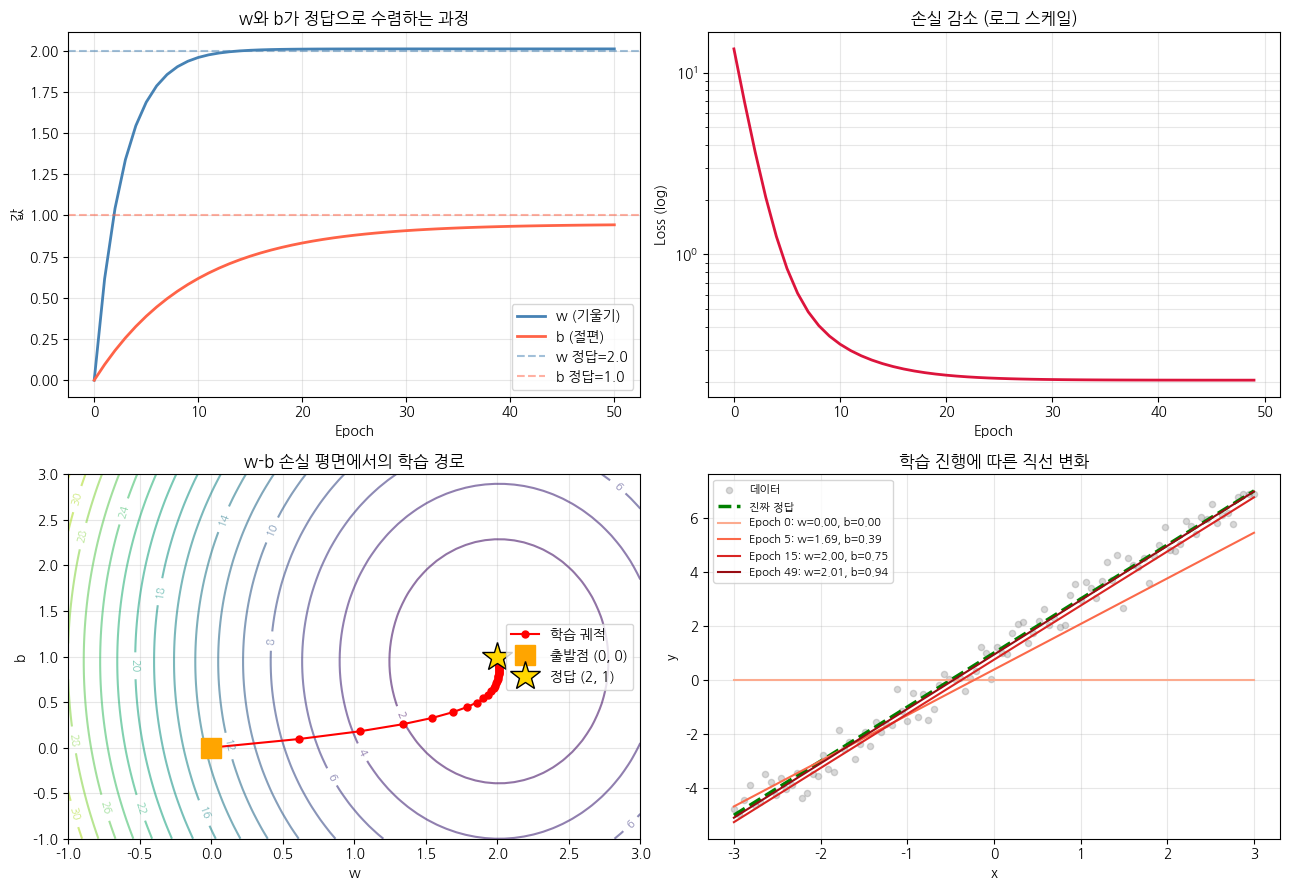

학습 결과:
   초기:  w=0.000, b=0.000, loss=13.4861
   최종:  w=2.011, b=0.943, loss=0.2038
   정답:  w=2.000, b=1.000


In [15]:
# 시각화 1: 학습 궤적 4패널
# 다시 학습하면서 모든 시점의 w, b 기록
tf.random.set_seed(42)
np.random.seed(42)
N = 100
x_data_v = np.linspace(-3, 3, N).astype(np.float32)
y_data_v = (2.0 * x_data_v + 1.0 + np.random.normal(0, 0.5, N)).astype(np.float32)

w_v = tf.Variable(0.0)
b_v = tf.Variable(0.0)
lr_v = 0.05

ws, bs, losses_v = [w_v.numpy()], [b_v.numpy()], []

for epoch in range(50):
    with tf.GradientTape() as tape:
        y_pred = w_v * x_data_v + b_v
        loss_v = tf.reduce_mean((y_pred - y_data_v) ** 2)
    dw, db = tape.gradient(loss_v, [w_v, b_v])
    w_v.assign_sub(lr_v * dw)
    b_v.assign_sub(lr_v * db)
    losses_v.append(loss_v.numpy())
    ws.append(w_v.numpy())
    bs.append(b_v.numpy())

# 4패널 시각화
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# (왼위) w와 b의 변화
axes[0, 0].plot(ws, label='w (기울기)', linewidth=2, color='steelblue')
axes[0, 0].plot(bs, label='b (절편)', linewidth=2, color='tomato')
axes[0, 0].axhline(2.0, color='steelblue', linestyle='--', alpha=0.5, label='w 정답=2.0')
axes[0, 0].axhline(1.0, color='tomato', linestyle='--', alpha=0.5, label='b 정답=1.0')
axes[0, 0].set_xlabel('Epoch'); axes[0, 0].set_ylabel('값')
axes[0, 0].set_title('w와 b가 정답으로 수렴하는 과정')
axes[0, 0].legend(); axes[0, 0].grid(alpha=0.3)

# (오른위) 손실 곡선 (로그 스케일)
axes[0, 1].plot(losses_v, color='crimson', linewidth=2)
axes[0, 1].set_xlabel('Epoch'); axes[0, 1].set_ylabel('Loss (log)')
axes[0, 1].set_title('손실 감소 (로그 스케일)')
axes[0, 1].set_yscale('log')
axes[0, 1].grid(alpha=0.3, which='both')

# (왼아래) w-b 평면에서의 학습 궤적 (등고선)
W_grid, B_grid = np.meshgrid(np.linspace(-1, 3, 60), np.linspace(-1, 3, 60))
loss_grid = np.zeros_like(W_grid)
for i in range(W_grid.shape[0]):
    for j in range(W_grid.shape[1]):
        pred = W_grid[i, j] * x_data_v + B_grid[i, j]
        loss_grid[i, j] = np.mean((pred - y_data_v) ** 2)

cs = axes[1, 0].contour(W_grid, B_grid, loss_grid, levels=15, cmap='viridis', alpha=0.6)
axes[1, 0].clabel(cs, inline=True, fontsize=8)
axes[1, 0].plot(ws, bs, 'o-', color='red', markersize=5, linewidth=1.5, label='학습 궤적')
axes[1, 0].plot(ws[0], bs[0], 's', color='orange', markersize=14, label='출발점 (0, 0)')
axes[1, 0].plot(2.0, 1.0, '*', color='gold', markersize=22, markeredgecolor='black', label='정답 (2, 1)')
axes[1, 0].set_xlabel('w'); axes[1, 0].set_ylabel('b')
axes[1, 0].set_title('w-b 손실 평면에서의 학습 경로')
axes[1, 0].legend(); axes[1, 0].grid(alpha=0.3)

# (오른아래) 직선이 진짜 정답에 가까워지는 모습
axes[1, 1].scatter(x_data_v, y_data_v, alpha=0.3, color='gray', s=20, label='데이터')
axes[1, 1].plot(x_data_v, 2 * x_data_v + 1, 'g--', linewidth=2.5, label='진짜 정답')
epochs_to_show = [0, 5, 15, 49]
colors_lines = plt.cm.Reds(np.linspace(0.3, 0.9, len(epochs_to_show)))
for ep, c in zip(epochs_to_show, colors_lines):
    line_y = ws[ep] * x_data_v + bs[ep]
    axes[1, 1].plot(x_data_v, line_y, color=c, linewidth=1.5,
                     label=f'Epoch {ep}: w={ws[ep]:.2f}, b={bs[ep]:.2f}')
axes[1, 1].set_xlabel('x'); axes[1, 1].set_ylabel('y')
axes[1, 1].set_title('학습 진행에 따른 직선 변화')
axes[1, 1].legend(fontsize=8); axes[1, 1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

print(f"학습 결과:")
print(f"   초기:  w=0.000, b=0.000, loss={losses_v[0]:.4f}")
print(f"   최종:  w={ws[-1]:.3f}, b={bs[-1]:.3f}, loss={losses_v[-1]:.4f}")
print(f"   정답:  w=2.000, b=1.000")

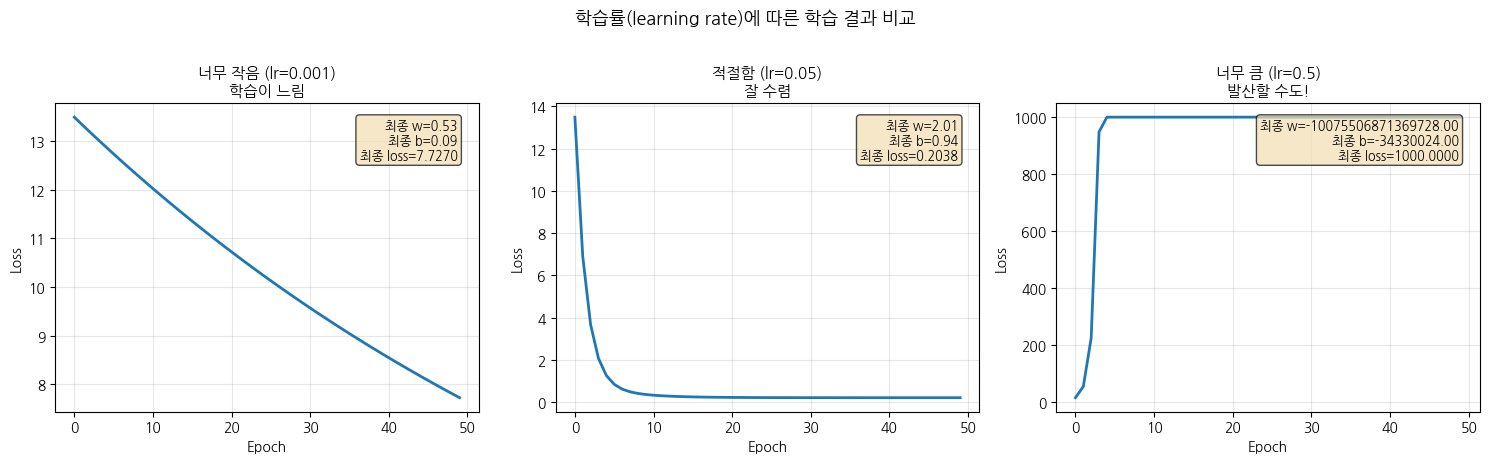

학습률 선택 가이드:
- 너무 작으면: 골짜기로 한 발씩만 나아가서 시간 너무 걸림
- 너무 크면: 골짜기를 지나쳐 반대편으로 튕겨감 (발산 가능)
- 적절한 값: 데이터마다 다르지만, 0.001 ~ 0.1 사이로 시작해보고 조정


In [16]:
# 시각화 2: 학습률(lr) 비교
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

learning_rates = [0.001, 0.05, 0.5]
titles = ['너무 작음 (lr=0.001)\n학습이 느림',
           '적절함 (lr=0.05)\n잘 수렴',
           '너무 큼 (lr=0.5)\n발산할 수도!']

for ax, lr, title in zip(axes, learning_rates, titles):
    tf.random.set_seed(42)
    np.random.seed(42)
    x_d = np.linspace(-3, 3, 100).astype(np.float32)
    y_d = (2.0 * x_d + 1.0 + np.random.normal(0, 0.5, 100)).astype(np.float32)
    w_t = tf.Variable(0.0)
    b_t = tf.Variable(0.0)

    losses_lr = []
    ws_lr, bs_lr = [0.0], [0.0]
    for _ in range(50):
        with tf.GradientTape() as tape:
            l_t = tf.reduce_mean((w_t * x_d + b_t - y_d) ** 2)
        dw, db = tape.gradient(l_t, [w_t, b_t])
        w_t.assign_sub(lr * dw)
        b_t.assign_sub(lr * db)
        losses_lr.append(min(float(l_t.numpy()), 1000))   # 폭발 방지 cap
        ws_lr.append(float(w_t.numpy()))
        bs_lr.append(float(b_t.numpy()))

    ax.plot(losses_lr, linewidth=2)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.grid(alpha=0.3)
    ax.text(0.95, 0.95, f'최종 w={ws_lr[-1]:.2f}\n최종 b={bs_lr[-1]:.2f}\n최종 loss={losses_lr[-1]:.4f}',
             transform=ax.transAxes, fontsize=9, va='top', ha='right',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

plt.suptitle('학습률(learning rate)에 따른 학습 결과 비교', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

print("학습률 선택 가이드:")
print("- 너무 작으면: 골짜기로 한 발씩만 나아가서 시간 너무 걸림")
print("- 너무 크면: 골짜기를 지나쳐 반대편으로 튕겨감 (발산 가능)")
print("- 적절한 값: 데이터마다 다르지만, 0.001 ~ 0.1 사이로 시작해보고 조정")

### 실습 2 추가 테스트: GradientTape 학습 검증

학습 루프가 제대로 동작하는지 다양한 케이스로 확인합니다.

In [17]:
# 추가 테스트: 5가지 케이스
print("=== 실습 2 종합 테스트 ===\n")
tests_passed = 0

# 테스트 1: 손실이 단조 감소 (대부분 epoch에서)
diffs = [losses_v[i+1] - losses_v[i] for i in range(len(losses_v)-1)]
n_decrease = sum(1 for d in diffs if d <= 0)
test1 = n_decrease >= len(diffs) * 0.8
print(f"[테스트 1] 손실 대부분 감소 (>=80%): {'OK' if test1 else 'FAIL'} ({n_decrease}/{len(diffs)} epoch)")
tests_passed += int(test1)

# 테스트 2: 최종 손실이 충분히 작은가
test2 = losses_v[-1] < 1.0
print(f"[테스트 2] 최종 손실 < 1.0: {'OK' if test2 else 'FAIL'} (최종: {losses_v[-1]:.4f})")
tests_passed += int(test2)

# 테스트 3: w, b가 정답에 충분히 가까운가
test3 = abs(ws[-1] - 2.0) < 0.3 and abs(bs[-1] - 1.0) < 0.3
print(f"[테스트 3] w, b가 정답에 가까움: {'OK' if test3 else 'FAIL'} (w={ws[-1]:.3f}, b={bs[-1]:.3f})")
tests_passed += int(test3)

# 테스트 4: GradientTape 안에서만 미분 추적되는가
w_test = tf.Variable(2.0)
with tf.GradientTape() as tape:
    y_t = w_test ** 2
grad_inside = tape.gradient(y_t, w_test)
# Tape 밖에서는 추적 안 됨 (None 반환)
y_outside = w_test ** 2
# 외부에서 호출하면 새 tape 필요 (있으면 실패)
test4 = grad_inside is not None and abs(grad_inside.numpy() - 4.0) < 1e-5  # 2x = 4
print(f"[테스트 4] GradientTape 안 미분 정확: {'OK' if test4 else 'FAIL'} (dy/dx at x=2: {grad_inside.numpy() if grad_inside is not None else None})")
tests_passed += int(test4)

# 테스트 5: 다른 정답으로도 학습 가능
tf.random.set_seed(0)
np.random.seed(0)
x_other = np.linspace(-2, 4, 80).astype(np.float32)
y_other = (-1.5 * x_other + 0.5 + np.random.normal(0, 0.3, 80)).astype(np.float32)
w_o = tf.Variable(0.0)
b_o = tf.Variable(0.0)
for _ in range(100):
    with tf.GradientTape() as tape:
        l_o = tf.reduce_mean((w_o * x_other + b_o - y_other) ** 2)
    dw, db = tape.gradient(l_o, [w_o, b_o])
    w_o.assign_sub(0.05 * dw)
    b_o.assign_sub(0.05 * db)
test5 = abs(float(w_o.numpy()) - (-1.5)) < 0.2 and abs(float(b_o.numpy()) - 0.5) < 0.3
print(f"[테스트 5] 다른 정답(w=-1.5, b=0.5)도 학습: {'OK' if test5 else 'FAIL'} (w={float(w_o.numpy()):.3f}, b={float(b_o.numpy()):.3f})")
tests_passed += int(test5)

print(f"\n전체: {tests_passed}/5 통과")
if tests_passed == 5:
    print("모든 테스트 통과! GradientTape 학습 루프가 완벽합니다.")

=== 실습 2 종합 테스트 ===

[테스트 1] 손실 대부분 감소 (>=80%): OK (49/49 epoch)
[테스트 2] 최종 손실 < 1.0: OK (최종: 0.2038)
[테스트 3] w, b가 정답에 가까움: OK (w=2.011, b=0.943)
[테스트 4] GradientTape 안 미분 정확: OK (dy/dx at x=2: 4.0)
[테스트 5] 다른 정답(w=-1.5, b=0.5)도 학습: OK (w=-1.558, b=0.549)

전체: 5/5 통과
모든 테스트 통과! GradientTape 학습 루프가 완벽합니다.


## 5. Sequential API - Keras의 마법

### Sequential이 뭐야?

> **Sequential = "층을 일렬로 쌓을 거야" 라고 알려주는 가장 단순한 모델 정의 방식**

PyTorch의 `nn.Sequential` 과 거의 같지만, Keras에서는 **이게 기본 사용법**입니다.

### 기본 사용법

```python
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(8,)),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)   # 회귀: 마지막 활성화 없음
])
```

### 학습은 단 3줄!

```python
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=30)
results = model.evaluate(X_test, y_test)
```

PyTorch에서는 `train_one_epoch` 함수를 직접 만들었지만,
**Keras는 `compile + fit` 으로 끝!**

### compile() 의 3가지 인자

| 인자 | 의미 | 예시 |
|---|---|---|
| `optimizer` | 어떻게 학습할까 | `'adam'`, `keras.optimizers.SGD(0.01)` |
| `loss` | 손실 함수 | `'mse'`, `'sparse_categorical_crossentropy'` |
| `metrics` | 모니터할 지표 | `['accuracy']`, `['mae', 'mse']` |

---

## 실습 3: Sequential로 회귀 모델 만들기

캘리포니아 주택 가격 예측 모델을 만듭니다 (입력 8 -> 64 -> 32 -> 1).

### 만들어야 할 함수
```python
build_housing_regressor(in_features)
# 반환: 컴파일까지 완료된 keras.Sequential 모델
```

### 힌트 - 2단계!

1. **모델 정의** (Sequential 안에 4개 레이어):
   ```python
   model = keras.Sequential([
       layers.Dense(64, activation='relu', input_shape=(in_features,)),
       layers.Dense(32, activation='relu'),
       layers.Dense(1),   # 회귀 - 활성화 없음!
   ])
   ```

2. **컴파일**:
   ```python
   model.compile(optimizer='adam', loss='mse', metrics=['mae'])
   ```

3. **반환**: `return model`

### 회귀 vs 분류 - 마지막 레이어 차이

| 문제 | 마지막 활성화 | 손실 |
|---|---|---|
| 회귀 (가격 등) | **없음** | `'mse'` |
| 이진 분류 | `'sigmoid'` | `'binary_crossentropy'` |
| 다중 분류 | `'softmax'` | `'sparse_categorical_crossentropy'` |

In [18]:
# 빈칸을 채워서 회귀 모델을 완성하세요!
def build_housing_regressor(in_features):
    # TODO 1: Sequential 모델 정의 (3개 Dense 레이어)
    model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(in_features,)),
    layers.Dense(32, activation='relu'),
    layers.Dense(1),   # 회귀 - 활성화 없음!
])


       # (힌트: keras.Sequential([...] 3개 Dense 레이어))
    # 안에 들어갈 레이어:
    #   1. Dense(64, activation='relu', input_shape=(in_features,))
    #   2. Dense(32, activation='relu')
    #   3. Dense(1)  # 마지막은 활성화 없음

    # TODO 2: 컴파일
    model.compile(
        optimizer="adam",   # (힌트: 'adam')
        loss="mse",        # (힌트: 'mse')
        metrics=['mae'],     # (힌트: ['mae']) mean absolute error
    )

    # TODO 3: 반환
    return model

In [19]:
# 자가 검증
try:
    model = build_housing_regressor(in_features=8)

    # 검증 1) Keras 모델인가?
    is_keras = isinstance(model, keras.Model)

    # 검증 2) 컴파일 됐는가?
    has_optimizer = model.optimizer is not None
    has_loss = model.compiled_loss is not None or hasattr(model, 'loss')

    # 검증 3) 입력 통과 테스트
    test_x = np.random.randn(16, 8).astype(np.float32)
    output = model(test_x)
    output_shape_ok = output.shape == (16, 1)

    # 검증 4) 파라미터 수 (8*64+64 + 64*32+32 + 32*1+1 = 2689)
    n_params = model.count_params()
    params_ok = n_params == 2689

    if is_keras and has_optimizer and output_shape_ok and params_ok:
        print(f"정답입니다!")
        print(f"\n   모델 구조:")
        model.summary()
        print(f"\n   입력 (16, 8) -> 출력 {output.shape}")
        print(f"   파라미터: {n_params:,}개")
    else:
        print(f"다시 시도해보세요.")
        print(f"   is_keras: {is_keras}")
        print(f"   has_optimizer: {has_optimizer}")
        print(f"   output shape: {output.shape} (기대: (16, 1))")
        print(f"   params: {n_params} (기대: 2,689)")
except Exception as e:
    print(f"에러: {e}")

정답입니다!

   모델 구조:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,689 (10.50 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)


   입력 (16, 8) -> 출력 (16, 1)
   파라미터: 2,689개


<details>
<summary>정답 보기 (클릭)</summary>

```python
def build_housing_regressor(in_features):
    model = keras.Sequential([
        layers.Dense(64, activation='relu', input_shape=(in_features,)),
        layers.Dense(32, activation='relu'),
        layers.Dense(1),
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model
```

**해설 - PyTorch와 비교**:

PyTorch (5편에서 본 것):
```python
class HousingRegressor(nn.Module):
    def __init__(self, in_features):
        super().__init__()
        self.fc1 = nn.Linear(in_features, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 1)
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)
```

Keras 버전이 **훨씬 짧고 직관적**입니다. 이게 Keras의 매력!

대신 복잡한 흐름이 필요할 때는 Functional API나 Subclass를 써야 합니다.

</details>

In [20]:
# 표준 정답 함수
def build_housing_regressor(in_features):
    model = keras.Sequential([
        layers.Dense(64, activation='relu', input_shape=(in_features,)),
        layers.Dense(32, activation='relu'),
        layers.Dense(1),
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

print("build_housing_regressor 준비 완료!")

build_housing_regressor 준비 완료!


### 실습 3 보강: 모델 구조와 가중치 시각화

회귀 모델이 어떻게 생겼는지, 학습 전 가중치는 어떤 분포인지 봅시다.

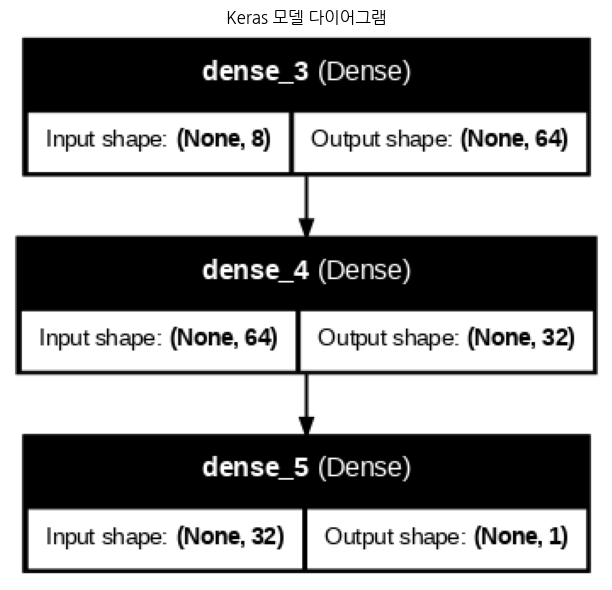

Keras plot_model로 그린 다이어그램


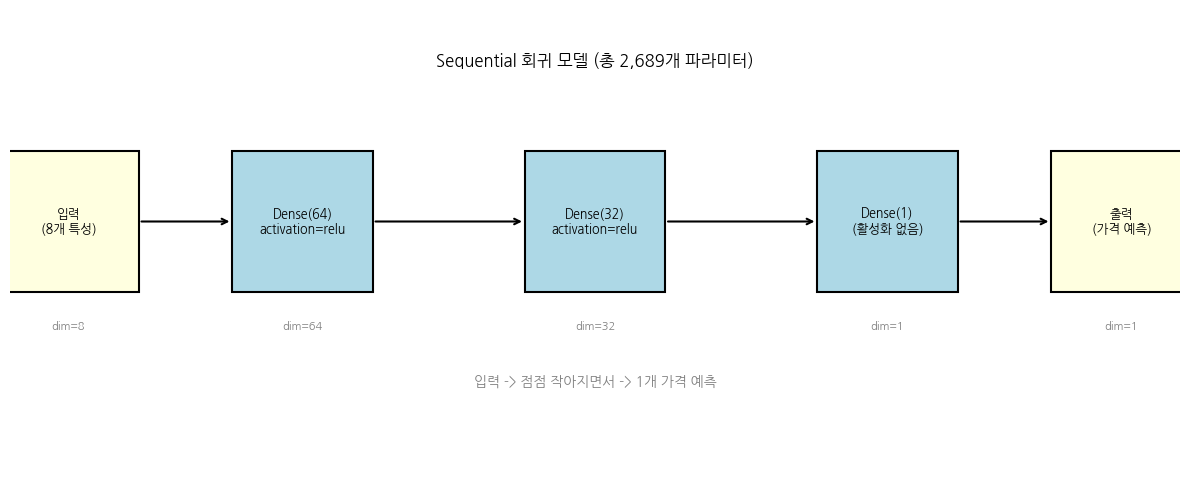


=== 레이어별 파라미터 ===
   dense_3    커널 (가중치): shape=(8, 64), 파라미터 512개
   dense_3    편향 (bias): shape=(64,), 파라미터 64개
   dense_4    커널 (가중치): shape=(64, 32), 파라미터 2,048개
   dense_4    편향 (bias): shape=(32,), 파라미터 32개
   dense_5    커널 (가중치): shape=(32, 1), 파라미터 32개
   dense_5    편향 (bias): shape=(1,), 파라미터 1개


In [21]:
# 시각화 1: Keras Sequential 모델 구조 다이어그램
model_check = build_housing_regressor(in_features=8)

# Keras 자체 plot_model 시도 (graphviz 있으면 됨)
try:
    keras.utils.plot_model(model_check, to_file='/tmp/model_diagram.png',
                            show_shapes=True, show_layer_names=True, dpi=70)
    img = plt.imread('/tmp/model_diagram.png')
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.imshow(img); ax.axis('off')
    ax.set_title('Keras 모델 다이어그램')
    plt.tight_layout(); plt.show()
    print("Keras plot_model로 그린 다이어그램")
except Exception as e:
    print(f"plot_model 실패 (graphviz 미설치): {e}")
    print("대신 직접 그림으로 보여드립니다.\n")

# 직접 다이어그램 (안전한 fallback)
fig, ax = plt.subplots(figsize=(12, 5))
ax.set_xlim(0, 10); ax.set_ylim(-1, 4); ax.axis('off')

nodes = [
    {'x': 0.5, 'label': '입력\n(8개 특성)', 'color': 'lightyellow', 'size': 8},
    {'x': 2.5, 'label': 'Dense(64)\nactivation=relu', 'color': 'lightblue', 'size': 64},
    {'x': 5.0, 'label': 'Dense(32)\nactivation=relu', 'color': 'lightblue', 'size': 32},
    {'x': 7.5, 'label': 'Dense(1)\n(활성화 없음)', 'color': 'lightblue', 'size': 1},
    {'x': 9.5, 'label': '출력\n(가격 예측)', 'color': 'lightyellow', 'size': 1},
]

for i, node in enumerate(nodes):
    rect = plt.Rectangle((node['x'] - 0.6, 1.0), 1.2, 1.5,
                          facecolor=node['color'], edgecolor='black', linewidth=1.5)
    ax.add_patch(rect)
    ax.text(node['x'], 1.75, node['label'], ha='center', va='center', fontsize=9)
    ax.text(node['x'], 0.6, f"dim={node['size']}", ha='center', fontsize=8, color='gray')
    if i < len(nodes) - 1:
        next_x = nodes[i+1]['x']
        ax.annotate('', xy=(next_x - 0.6, 1.75), xytext=(node['x'] + 0.6, 1.75),
                     arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

n_params = model_check.count_params()
ax.text(5, 3.4, f'Sequential 회귀 모델 (총 {n_params:,}개 파라미터)',
         ha='center', fontsize=12, fontweight='bold')
ax.text(5, 0.0, '입력 -> 점점 작아지면서 -> 1개 가격 예측',
         ha='center', fontsize=10, style='italic', color='gray')

plt.tight_layout(); plt.show()

# 레이어별 가중치 정보
print("\n=== 레이어별 파라미터 ===")
for layer in model_check.layers:
    weights = layer.get_weights()
    if weights:
        for w_idx, w in enumerate(weights):
            kind = '커널 (가중치)' if w_idx == 0 else '편향 (bias)'
            print(f"   {layer.name:10s} {kind}: shape={w.shape}, 파라미터 {w.size:,}개")

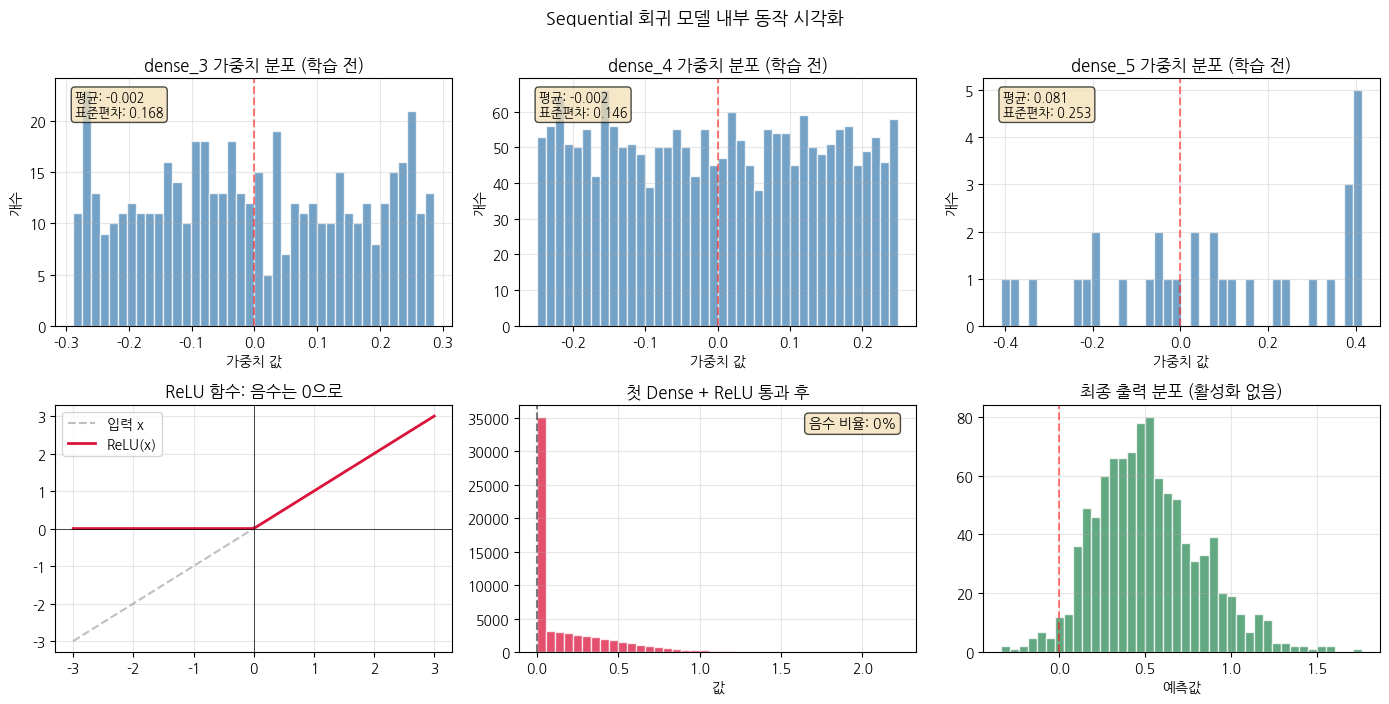

관찰 포인트:
- 가중치는 0 근처에 분포 (Keras 기본 Glorot 초기화)
- ReLU 후에는 음수가 모두 0으로 잘림
- 마지막 출력은 활성화가 없어서 음수도 양수도 가능 (회귀니까!)


In [22]:
# 시각화 2: 학습 전 가중치 분포 + ReLU 활성화 효과
fig, axes = plt.subplots(2, 3, figsize=(14, 7))

# 첫 행: 각 Dense 레이어의 커널(weight) 분포 (학습 전 = Glorot 초기화)
dense_layers = [l for l in model_check.layers if isinstance(l, layers.Dense)]
for i, layer in enumerate(dense_layers):
    weights = layer.get_weights()[0]   # kernel
    flat = weights.flatten()
    axes[0, i].hist(flat, bins=40, color='steelblue', alpha=0.75, edgecolor='white')
    axes[0, i].set_title(f'{layer.name} 가중치 분포 (학습 전)')
    axes[0, i].set_xlabel('가중치 값')
    axes[0, i].set_ylabel('개수')
    axes[0, i].axvline(0, color='red', linestyle='--', alpha=0.5)
    axes[0, i].grid(alpha=0.3)
    axes[0, i].text(0.05, 0.95, f'평균: {flat.mean():.3f}\n표준편차: {flat.std():.3f}',
                     transform=axes[0, i].transAxes, fontsize=9, va='top',
                     bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

# 둘째 행: ReLU 효과 시연
x_axis = np.linspace(-3, 3, 100)
axes[1, 0].plot(x_axis, x_axis, '--', color='gray', alpha=0.5, label='입력 x')
axes[1, 0].plot(x_axis, np.maximum(0, x_axis), color='crimson', linewidth=2, label='ReLU(x)')
axes[1, 0].axhline(0, color='black', linewidth=0.5)
axes[1, 0].axvline(0, color='black', linewidth=0.5)
axes[1, 0].set_title('ReLU 함수: 음수는 0으로')
axes[1, 0].legend(); axes[1, 0].grid(alpha=0.3)

# 진짜 데이터 통과 - 첫 번째 Dense 후 분포
test_input = np.random.randn(1000, 8).astype(np.float32)
# 모델을 한 번 호출해서 build
_ = model_check(test_input)

# 첫 번째 Dense 레이어를 직접 호출 (가장 간단한 방법!)
after_first = dense_layers[0](test_input).numpy()

axes[1, 1].hist(after_first.flatten(), bins=40, color='crimson', alpha=0.75, edgecolor='white')
axes[1, 1].set_title('첫 Dense + ReLU 통과 후')
axes[1, 1].set_xlabel('값'); axes[1, 1].grid(alpha=0.3)
axes[1, 1].axvline(0, color='black', linestyle='--', alpha=0.5)
axes[1, 1].text(0.95, 0.95, f'음수 비율: {(after_first.flatten() < 0).mean():.0%}',
                 transform=axes[1, 1].transAxes, fontsize=10, va='top', ha='right',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

# 마지막 출력 (회귀 - 활성화 없음)
final_output = model_check(test_input).numpy()
axes[1, 2].hist(final_output.flatten(), bins=40, color='seagreen', alpha=0.75, edgecolor='white')
axes[1, 2].set_title('최종 출력 분포 (활성화 없음)')
axes[1, 2].set_xlabel('예측값'); axes[1, 2].grid(alpha=0.3)
axes[1, 2].axvline(0, color='red', linestyle='--', alpha=0.5)

plt.suptitle('Sequential 회귀 모델 내부 동작 시각화', fontsize=13, y=1.00)
plt.tight_layout(); plt.show()

print("관찰 포인트:")
print("- 가중치는 0 근처에 분포 (Keras 기본 Glorot 초기화)")
print("- ReLU 후에는 음수가 모두 0으로 잘림")
print("- 마지막 출력은 활성화가 없어서 음수도 양수도 가능 (회귀니까!)")

### 실습 3 추가 테스트: 다양한 케이스 검증

회귀 모델이 다양한 입력에 안정적으로 동작하는지 확인합니다.

In [23]:
# 추가 테스트: 5가지 케이스
print("=== 실습 3 종합 테스트 ===\n")
tests_passed = 0

# 테스트 1: 다양한 배치 크기
test1 = True
for bs in [1, 16, 64, 256]:
    try:
        out = model_check(np.random.randn(bs, 8).astype(np.float32))
        if out.shape != (bs, 1):
            test1 = False; break
    except:
        test1 = False; break
print(f"[테스트 1] 배치 1, 16, 64, 256 통과: {'OK' if test1 else 'FAIL'}")
tests_passed += int(test1)

# 테스트 2: 다른 in_features 로도 만들 수 있는가
try:
    model_4 = build_housing_regressor(in_features=4)
    out_4 = model_4(np.random.randn(8, 4).astype(np.float32))
    test2 = out_4.shape == (8, 1)
except:
    test2 = False
print(f"[테스트 2] in_features=4 로도 만들기 가능: {'OK' if test2 else 'FAIL'}")
tests_passed += int(test2)

# 테스트 3: 옵티마이저, 손실 함수 설정 됐는가
test3 = (model_check.optimizer is not None) and (model_check.loss is not None)
print(f"[테스트 3] compile 완료 (optimizer + loss): {'OK' if test3 else 'FAIL'}")
tests_passed += int(test3)

# 테스트 4: 결정론적 - 같은 입력 -> 같은 출력 (training=False)
zero_input = np.zeros((1, 8), dtype=np.float32)
out1 = model_check(zero_input).numpy()
out2 = model_check(zero_input).numpy()
test4 = np.allclose(out1, out2)
print(f"[테스트 4] 같은 입력 -> 같은 출력 (결정론적): {'OK' if test4 else 'FAIL'}")
tests_passed += int(test4)

# 테스트 5: fit() 한 줄로 학습 가능한가 (가짜 데이터로 1 step)
fake_x = np.random.randn(100, 8).astype(np.float32)
fake_y = np.random.randn(100).astype(np.float32)
try:
    history = model_check.fit(fake_x, fake_y, epochs=1, verbose=0, batch_size=32)
    initial_loss = history.history['loss'][0]
    test5 = initial_loss > 0   # 손실이 계산되어야 함
except Exception as e:
    test5 = False
    print(f"   에러: {e}")
print(f"[테스트 5] fit() 으로 학습 가능: {'OK' if test5 else 'FAIL'}")
tests_passed += int(test5)

print(f"\n전체: {tests_passed}/5 통과")
if tests_passed == 5:
    print("모든 테스트 통과! 모델이 올바르게 만들어졌고 학습 준비가 되었습니다.")

=== 실습 3 종합 테스트 ===

[테스트 1] 배치 1, 16, 64, 256 통과: OK
[테스트 2] in_features=4 로도 만들기 가능: OK
[테스트 3] compile 완료 (optimizer + loss): OK
[테스트 4] 같은 입력 -> 같은 출력 (결정론적): OK
[테스트 5] fit() 으로 학습 가능: OK

전체: 5/5 통과
모든 테스트 통과! 모델이 올바르게 만들어졌고 학습 준비가 되었습니다.


## 6. 진짜 데이터로 학습 - 캘리포니아 주택 가격

PyTorch 노트북과 같은 데이터로 해봅시다.

In [24]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1) 데이터 로드
print("데이터 다운로드 중...")
data = fetch_california_housing()
X = data.data.astype(np.float32)
y = data.target.astype(np.float32)
print(f"   샘플: {X.shape[0]:,}개, 특성: {X.shape[1]}개")

# 2) 분할
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.2, random_state=42)

# 3) 표준화
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_val = scaler.transform(X_val).astype(np.float32)
X_test = scaler.transform(X_test).astype(np.float32)

print(f"   train: {len(X_train):,} / val: {len(X_val):,} / test: {len(X_test):,}")

데이터 다운로드 중...
   샘플: 20,640개, 특성: 8개
   train: 13,209 / val: 3,303 / test: 4,128


학습 시작...
   Epoch   1 | train MSE 1.3877 | val MSE 0.6956
   Epoch   5 | train MSE 0.3552 | val MSE 0.3694
   Epoch  10 | train MSE 0.3236 | val MSE 0.3503
   Epoch  15 | train MSE 0.3036 | val MSE 0.3314
   Epoch  20 | train MSE 0.2978 | val MSE 0.3386
   Epoch  25 | train MSE 0.2929 | val MSE 0.3461
   Epoch  30 | train MSE 0.2803 | val MSE 0.3055


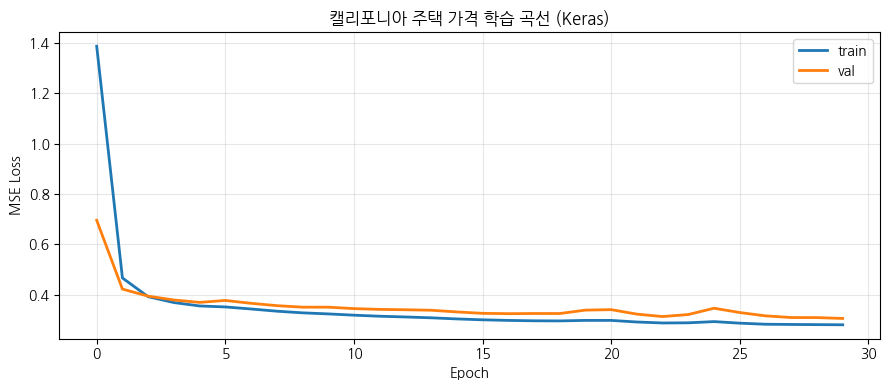


테스트 MSE: 0.3085
테스트 MAE: 0.3866 (= 평균 $38,660 오차)


In [25]:
# Keras 학습 - 진짜 한 줄!
set_seed(42)
model_reg = build_housing_regressor(in_features=8)

print("학습 시작...")
history = model_reg.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=64,
    verbose=0,   # 자세한 로그 끄기
)

# 5 epoch마다 진행 상황 출력
for epoch in [0, 4, 9, 14, 19, 24, 29]:
    if epoch < len(history.history['loss']):
        print(f"   Epoch {epoch+1:3d} | "
              f"train MSE {history.history['loss'][epoch]:.4f} | "
              f"val MSE {history.history['val_loss'][epoch]:.4f}")

# 학습 곡선
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(history.history['loss'], label='train', linewidth=2)
ax.plot(history.history['val_loss'], label='val', linewidth=2)
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
ax.set_title('캘리포니아 주택 가격 학습 곡선 (Keras)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# 평가
test_loss, test_mae = model_reg.evaluate(X_test, y_test, verbose=0)
print(f"\n테스트 MSE: {test_loss:.4f}")
print(f"테스트 MAE: {test_mae:.4f} (= 평균 ${test_mae*100000:,.0f} 오차)")

## 7. Functional API - 더 유연한 모델 설계

### Sequential의 한계

Sequential은 **층을 일렬로만** 쌓을 수 있어요. 하지만 실무 모델은 종종:
- 입력이 여러 개
- 출력이 여러 개
- 중간에 갈라지고 다시 합쳐짐 (스킵 연결, ResNet 등)

이런 경우 Functional API가 필요합니다.

### 기본 패턴

```python
inputs = keras.Input(shape=(8,))                   # 1) 입력 정의
x = layers.Dense(64, activation='relu')(inputs)    # 2) 레이어를 함수처럼 호출
x = layers.Dense(32, activation='relu')(x)         #    이전 결과를 다음에 전달
outputs = layers.Dense(1)(x)                       # 3) 출력
model = keras.Model(inputs, outputs)               # 4) 입력/출력으로 모델 정의
```

> **핵심**: 레이어를 `()` 로 호출해서 텐서를 통과시킵니다 - 이게 Functional!

### 진짜 매력 - 갈라지는 모델

```
입력
 ├── 깊은 경로 (Dense -> Dense -> Dense)
 └── 얕은 경로 (Dense)
       │
       v
   합치기 (Concatenate)
       │
       v
     출력
```

이런 와이드앤딥(Wide & Deep) 모델은 Sequential로 만들 수 없지만 Functional로는 자연스럽습니다.

In [26]:
# 와이드앤딥 (Wide & Deep) 예시 - 같은 데이터로 두 경로
inputs = keras.Input(shape=(8,), name='features')

# 깊은(deep) 경로 - 복잡한 특징 학습
deep = layers.Dense(64, activation='relu')(inputs)
deep = layers.Dense(32, activation='relu')(deep)

# 얕은(wide) 경로 - 입력을 그대로 활용
wide = inputs

# 두 경로 합치기
merged = layers.Concatenate()([wide, deep])
outputs = layers.Dense(1)(merged)

# 모델 만들기
wide_deep = keras.Model(inputs=inputs, outputs=outputs, name='wide_and_deep')
wide_deep.compile(optimizer='adam', loss='mse', metrics=['mae'])

print("Wide & Deep 모델 구조:")
wide_deep.summary()

# 시각화
try:
    keras.utils.plot_model(wide_deep, show_shapes=True, dpi=70)
    print("\n(코랩에서는 모델 다이어그램이 위에 표시됩니다)")
except:
    pass

Wide & Deep 모델 구조:


Model: "wide_and_deep"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ features            │ (None, 8)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 64)        │        576 │ features[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 32)        │      2,080 │ dense_12[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 40)        │          0 │ features[0][0],   │
│ (Concatenate)       │                   │            │ dense_13[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 1)         │         41 │ concatenate[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,697 (10.54 KB)

 Trainable params: 2,697 (10.54 KB)

 Non-trainable params: 0 (0.00 B)


(코랩에서는 모델 다이어그램이 위에 표시됩니다)


## 8. CNN으로 Fashion MNIST 분류

### 데이터 소개 (PyTorch와 같은 데이터)

> **Fashion MNIST** = 옷/신발 흑백 이미지 28x28, 10가지 카테고리

### TF/Keras에서 데이터 로드

`keras.datasets.fashion_mnist.load_data()` 한 줄로 다운로드 + 로드

Fashion MNIST 다운로드 중...
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
   train: (60000, 28, 28)
   test:  (10000, 28, 28)


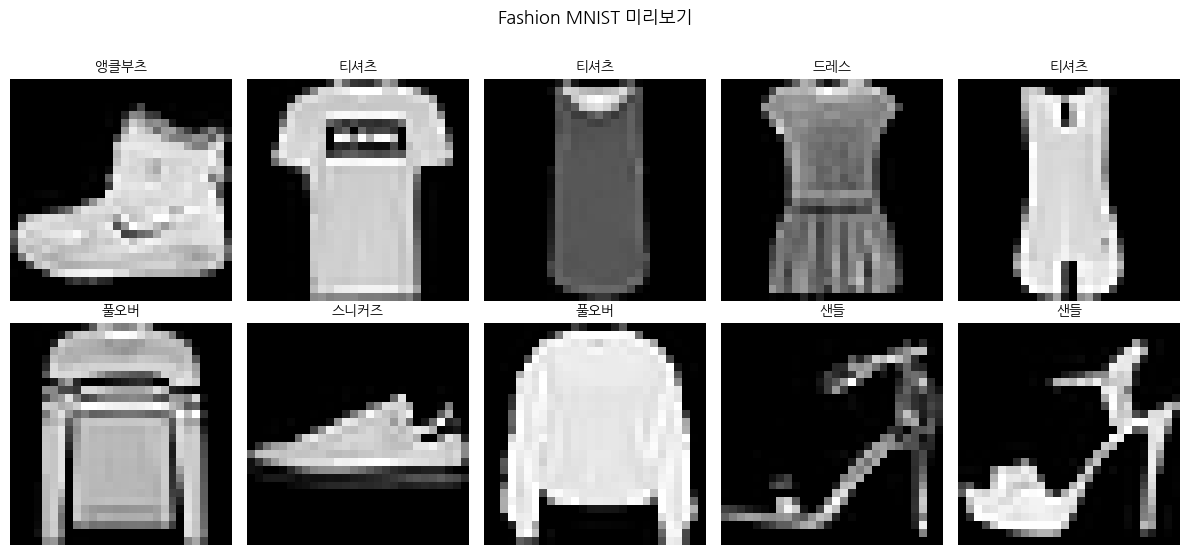


전처리 후:
   train: (48000, 28, 28, 1), val: (12000, 28, 28, 1), test: (10000, 28, 28, 1)
   픽셀 범위: [0.00, 1.00]


In [27]:
# Fashion MNIST 다운로드
print("Fashion MNIST 다운로드 중...")
(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()
print(f"   train: {x_train_full.shape}")
print(f"   test:  {x_test.shape}")

# 클래스 이름
class_names = ['티셔츠', '바지', '풀오버', '드레스', '코트',
                '샌들', '셔츠', '스니커즈', '가방', '앵클부츠']

# 데이터 미리보기
fig, axes = plt.subplots(2, 5, figsize=(12, 5.5))
for ax, idx in zip(axes.flatten(), range(10)):
    ax.imshow(x_train_full[idx], cmap='gray')
    ax.set_title(class_names[y_train_full[idx]], fontsize=10)
    ax.axis('off')
plt.suptitle('Fashion MNIST 미리보기', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

# 전처리: 0-255 -> 0-1, 채널 차원 추가
# TF 채널 위치: (N, H, W, C) - PyTorch와 다름!
x_train_full = (x_train_full.astype(np.float32) / 255.0)[..., np.newaxis]
x_test = (x_test.astype(np.float32) / 255.0)[..., np.newaxis]

# train/val 분할 (마지막 20%를 val로)
val_size = len(x_train_full) // 5
x_train = x_train_full[:-val_size]
y_train = y_train_full[:-val_size]
x_val = x_train_full[-val_size:]
y_val = y_train_full[-val_size:]

print(f"\n전처리 후:")
print(f"   train: {x_train.shape}, val: {x_val.shape}, test: {x_test.shape}")
print(f"   픽셀 범위: [{x_train.min():.2f}, {x_train.max():.2f}]")

---

## 실습 4: Functional API로 CNN 만들기

PyTorch 노트북에서 만든 FashionCNN 과 같은 구조를 Functional API로 만들어 봅시다.

### 만들어야 할 함수
```python
build_fashion_cnn()
# Functional API로 CNN 구성
# 반환: 컴파일까지 완료된 keras.Model
```

### 구조 (PyTorch와 동일)

```
입력 (28, 28, 1)
   |
   v Conv2D(32, 3, padding='same') + ReLU
   v MaxPool2D(2)            -> (14, 14, 32)
   v Conv2D(64, 3, padding='same') + ReLU
   v MaxPool2D(2)            -> (7, 7, 64)
   v Conv2D(64, 3, padding='same') + ReLU
   v Flatten                 -> (3136,)
   v Dense(64) + ReLU
   v Dropout(0.3)
   v Dense(10, softmax)      <- 다중분류!
출력 (10,) - 클래스별 확률
```

### 힌트 - Functional API 패턴

```python
inputs = keras.Input(shape=(28, 28, 1))

x = layers.Conv2D(32, 3, padding='same', activation='relu')(inputs)
x = layers.MaxPooling2D(2)(x)
x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
x = layers.MaxPooling2D(2)(x)
x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
x = layers.Flatten()(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(10, activation='softmax')(x)

model = keras.Model(inputs, outputs, name='fashion_cnn')
model.compile(...)
return model
```

### Keras vs PyTorch 마지막 레이어 차이

| | Keras | PyTorch |
|---|---|---|
| 마지막 활성화 | `softmax` 명시 | 없음 (CrossEntropyLoss가 안에서 처리) |
| 손실 함수 | `'sparse_categorical_crossentropy'` | `nn.CrossEntropyLoss()` |

In [28]:
# 빈칸을 채워서 Functional API CNN 을 완성하세요!
def build_fashion_cnn():
    # TODO 1: 입력 정의
    inputs = keras.Input(shape=(28, 28, 1))   # (힌트: keras.Input(shape=(28, 28, 1)))

    # TODO 2: 합성곱 블록 (Functional API - 레이어를 함수처럼 호출)
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(inputs) #(1,28,28,1) => (1,28,28,32) #샘플 장수, 세로, 가로, 채널
    x = layers.MaxPooling2D(2)(x)                                       #(1,28,28,32) => (1,14,14,32)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)      #(1,14,14,32) => (1,14,14,64)
    x = layers.MaxPooling2D(2)(x)                                       #(1,14,14,64) => (1,7,7,64)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)      #(1,7,7,64)

    # TODO 3: 분류 헤드
    x = layers.Flatten()(x)                                             #(1,7,7,64)=> (1, 7*7*64)
    x = layers.Dense(64, activation='relu')(x)                          #(1, 7*7*64)(7*7*64 ,64) => (1,64)
    x = layers.Dropout(0.3)(x)                                          #30%만 남기고 줄인다.
    outputs = layers.Dense(10, activation='softmax')(x)                 #(1,64)(64*10) => (1,10)

    # TODO 4: 모델 만들기
    model = keras.Model(inputs, outputs, name='fashion_cnn')   # (힌트: keras.Model(inputs, outputs, name='fashion_cnn'))

    # TODO 5: 컴파일
    model.compile(
        optimizer='adam',   # (힌트: 'adam')
        loss= 'sparse_categorical_crossentropy',        # (힌트: 'sparse_categorical_crossentropy')
        metrics=['accuracy']
    )

    return model

In [29]:
# 자가 검증
try:
    cnn = build_fashion_cnn()

    # 검증 1) Keras 모델
    is_keras = isinstance(cnn, keras.Model)

    # 검증 2) 입출력 shape
    test_input = np.random.randn(4, 28, 28, 1).astype(np.float32)
    output = cnn(test_input)
    output_shape_ok = output.shape == (4, 10)

    # 검증 3) softmax 출력 (각 행 합 = 1)
    probs_sum_ok = np.allclose(np.sum(output.numpy(), axis=1), 1.0, atol=1e-5)

    # 검증 4) 컴파일 됐는가
    has_optimizer = cnn.optimizer is not None

    # 검증 5) 파라미터 수 (PyTorch와 비슷한 257K 정도)
    # 파라미터가 학습에 필요한 재료. 특성.
    # 파라미터가 없더라도(flatten, dropout, maxpooling)도 미분해서 역전파한다.
    n_params = cnn.count_params()
    params_ok = 100000 < n_params < 500000

    if is_keras and output_shape_ok and probs_sum_ok and has_optimizer and params_ok:
        print(f"정답입니다!")
        print(f"\n   모델 구조:")
        cnn.summary()
        print(f"\n   입력 (4, 28, 28, 1) -> 출력 {output.shape}")
        print(f"   softmax 합 (4 샘플): {np.sum(output.numpy(), axis=1)}")
        print(f"   파라미터: {n_params:,}개")
    else:
        print(f"다시 시도해보세요.")
        print(f"   output shape: {output.shape} (기대: (4, 10))")
        print(f"   softmax 합 = 1: {probs_sum_ok}")
        print(f"   has_optimizer: {has_optimizer}")
except Exception as e:
    print(f"에러: {e}")

정답입니다!

   모델 구조:


Model: "fashion_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 257,162 (1004.54 KB)

 Trainable params: 257,162 (1004.54 KB)

 Non-trainable params: 0 (0.00 B)


   입력 (4, 28, 28, 1) -> 출력 (4, 10)
   softmax 합 (4 샘플): [0.99999994 1.         0.99999994 0.99999994]
   파라미터: 257,162개


<details>
<summary>정답 보기 (클릭)</summary>

```python
def build_fashion_cnn():
    inputs = keras.Input(shape=(28, 28, 1))

    x = layers.Conv2D(32, 3, padding='same', activation='relu')(inputs)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.Flatten()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(10, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name='fashion_cnn')
    model.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])
    return model
```

**해설**:

| 손실 함수 이름 | 언제 쓰나 | 라벨 형식 |
|---|---|---|
| `sparse_categorical_crossentropy` | 라벨이 정수 (예: 3) | `[2, 5, 1, 3, ...]` |
| `categorical_crossentropy` | 라벨이 원핫 벡터 | `[[0,0,1,0,0,...]]` |
| `binary_crossentropy` | 이진 분류 | `[0, 1, 1, 0, ...]` |

대부분 `sparse_categorical_crossentropy` 가 편합니다 (정수 라벨 그대로 쓸 수 있음).

</details>

In [30]:
# 표준 정답 함수
def build_fashion_cnn():
    inputs = keras.Input(shape=(28, 28, 1))
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(inputs)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.Flatten()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(10, activation='softmax')(x)
    model = keras.Model(inputs, outputs, name='fashion_cnn')
    model.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])
    return model

print("build_fashion_cnn 준비 완료!")

build_fashion_cnn 준비 완료!


### 실습 4 보강: CNN 내부 들여다보기

Functional API CNN이 이미지를 통과시키며 어떻게 변화하는지 살펴봅시다.
- 각 레이어 출력 shape 추적
- 같은 이미지가 각 conv 레이어에서 어떻게 변환되나? (feature map)
- 학습 전과 후의 차이

In [31]:
# 시각화 1: 각 레이어 출력 shape 추적
cnn_check = build_fashion_cnn()

print("=== Fashion CNN 레이어별 출력 shape ===\n")
print(f"{'레이어 이름':30s} {'타입':18s} {'출력 shape'}")
print("-" * 70)
for layer in cnn_check.layers:
    output_shape = layer.output_shape if hasattr(layer, 'output_shape') else 'N/A'
    layer_type = layer.__class__.__name__
    print(f"{layer.name:30s} {layer_type:18s} {output_shape}")

# 흐름 시각화
print("\n핵심 흐름:")
print("   28x28x1 -> Conv -> 28x28x32 -> Pool -> 14x14x32")
print("           -> Conv -> 14x14x64 -> Pool -> 7x7x64")
print("           -> Conv -> 7x7x64 -> Flatten -> 3136 -> Dense -> 64 -> 10")
print("\n공간 크기는 줄고, 채널 수는 늘어나는 표준 CNN 패턴!")

=== Fashion CNN 레이어별 출력 shape ===

레이어 이름                         타입                 출력 shape
----------------------------------------------------------------------
input_layer_5                  InputLayer         N/A
conv2d_3                       Conv2D             N/A
max_pooling2d_2                MaxPooling2D       N/A
conv2d_4                       Conv2D             N/A
max_pooling2d_3                MaxPooling2D       N/A
conv2d_5                       Conv2D             N/A
flatten_1                      Flatten            N/A
dense_17                       Dense              N/A
dropout_1                      Dropout            N/A
dense_18                       Dense              N/A

핵심 흐름:
   28x28x1 -> Conv -> 28x28x32 -> Pool -> 14x14x32
           -> Conv -> 14x14x64 -> Pool -> 7x7x64
           -> Conv -> 7x7x64 -> Flatten -> 3136 -> Dense -> 64 -> 10

공간 크기는 줄고, 채널 수는 늘어나는 표준 CNN 패턴!


Conv 레이어 3개 발견:
   conv2d_3: 출력 shape (None, 28, 28, 32)
   conv2d_4: 출력 shape (None, 14, 14, 64)
   conv2d_5: 출력 shape (None, 7, 7, 64)


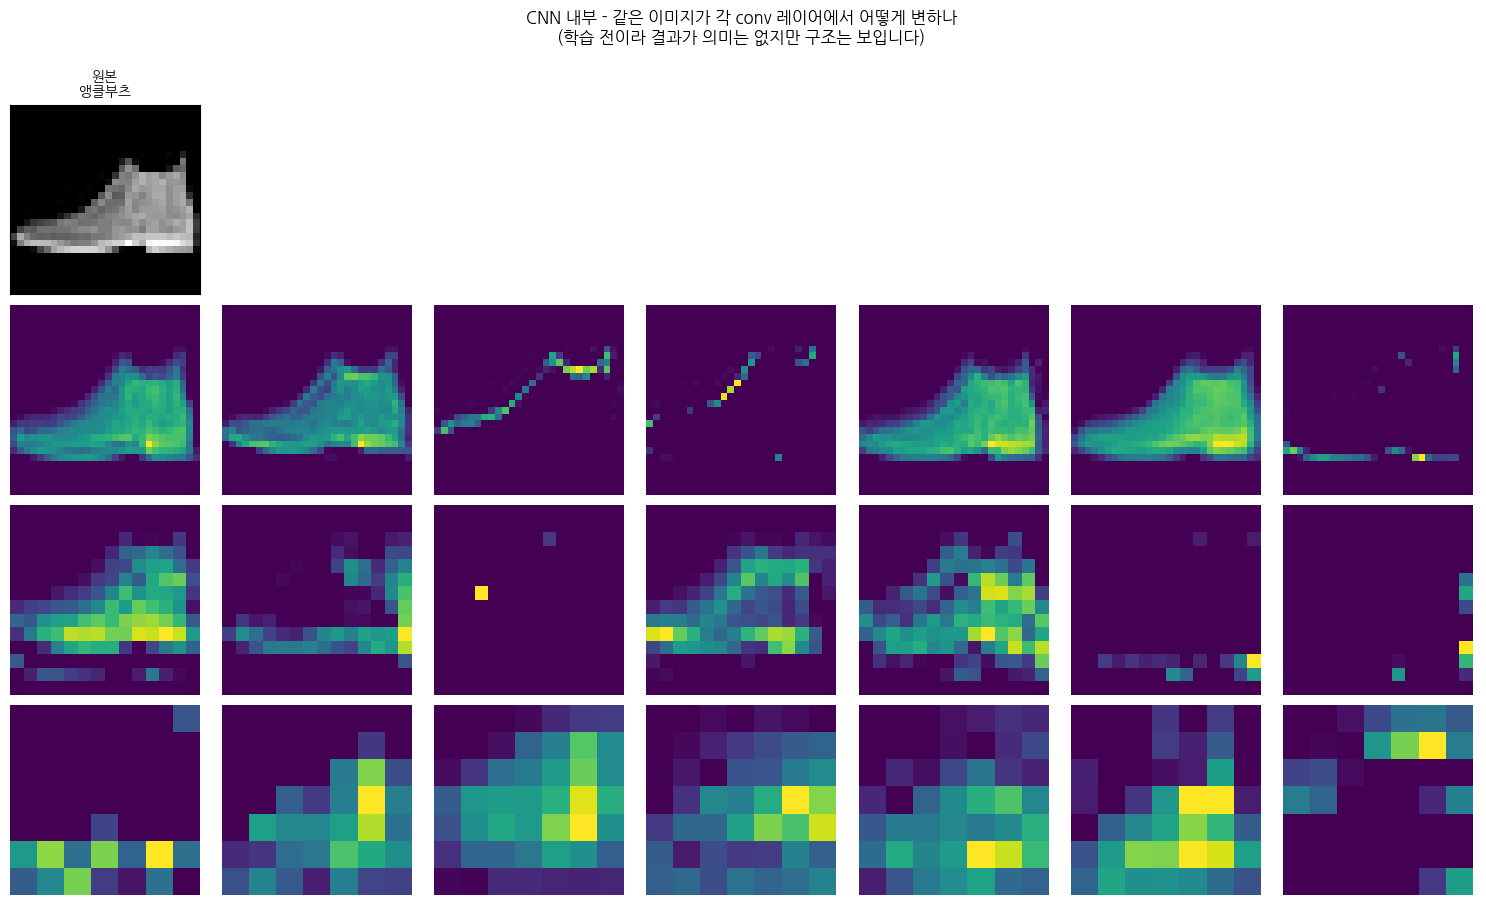


Functional API의 강점:
- 중간 레이어 출력을 가져오는 새 모델을 한 줄로 만들 수 있음!
- intermediate_model = keras.Model(inputs=cnn.inputs, outputs=conv_layer.output)
- 학습 후에는 각 채널이 의미 있는 패턴(엣지, 텍스처)을 검출하게 됩니다


In [32]:
# 시각화 2: Feature Map 시각화 - Keras Model로 중간 출력 가져오기
# Functional API의 강력한 기능: 중간 레이어 출력을 가진 새 모델을 즉석에서 만들 수 있음

# 각 conv 레이어 이름 찾기
conv_layers = [l for l in cnn_check.layers if 'conv' in l.name.lower()]
print(f"Conv 레이어 {len(conv_layers)}개 발견:")
for cl in conv_layers:
    print(f"   {cl.name}: 출력 shape {cl.output.shape}")

# 각 conv 레이어의 출력을 동시에 내보내는 새 모델 만들기
intermediate_outputs = [layer.output for layer in conv_layers]
intermediate_model = keras.Model(inputs=cnn_check.inputs, outputs=intermediate_outputs)

# Fashion MNIST 이미지 1장으로 통과
sample_idx = 0
sample_input = x_test[sample_idx:sample_idx+1]   # (1, 28, 28, 1)

# 모든 conv 출력 한 번에 가져오기
feature_maps = intermediate_model(sample_input)
if not isinstance(feature_maps, list):
    feature_maps = [feature_maps]

# 시각화: 원본 + 각 conv의 첫 6개 채널
fig, axes = plt.subplots(4, 7, figsize=(15, 9))

# 첫 행: 원본
axes[0, 0].imshow(sample_input[0, :, :, 0], cmap='gray')
axes[0, 0].set_title(f'원본\n{class_names[y_test[sample_idx]]}', fontsize=10)
for j in range(1, 7):
    axes[0, j].axis('off')
axes[0, 0].set_xticks([]); axes[0, 0].set_yticks([])

# 2~4행: 각 conv 출력의 첫 6개 채널
for row, (cl, fmap) in enumerate(zip(conv_layers, feature_maps), start=1):
    fmap_np = fmap[0].numpy()   # (H, W, C)
    label = f'{cl.name}\n{fmap_np.shape}'
    axes[row, 0].set_ylabel(label, fontsize=9, rotation=0,
                              labelpad=55, va='center', ha='right')
    for col in range(7):
        if col < min(7, fmap_np.shape[-1]):
            axes[row, col].imshow(fmap_np[:, :, col], cmap='viridis')
        axes[row, col].axis('off')

plt.suptitle('CNN 내부 - 같은 이미지가 각 conv 레이어에서 어떻게 변하나\n(학습 전이라 결과가 의미는 없지만 구조는 보입니다)',
              fontsize=12, y=1.00)
plt.tight_layout(); plt.show()

print("\nFunctional API의 강점:")
print("- 중간 레이어 출력을 가져오는 새 모델을 한 줄로 만들 수 있음!")
print("- intermediate_model = keras.Model(inputs=cnn.inputs, outputs=conv_layer.output)")
print("- 학습 후에는 각 채널이 의미 있는 패턴(엣지, 텍스처)을 검출하게 됩니다")

### 실습 4 추가 테스트: CNN 동작 검증

다양한 케이스로 CNN이 제대로 만들어졌는지 확인합니다.

In [33]:
# 추가 테스트: 5가지 케이스
print("=== 실습 4 종합 테스트 ===\n")
tests_passed = 0

# 테스트 1: 다양한 배치 크기
test1 = True
for bs in [1, 8, 32, 128]:
    try:
        out = cnn_check(np.random.randn(bs, 28, 28, 1).astype(np.float32))
        if out.shape != (bs, 10):
            test1 = False; break
    except:
        test1 = False; break
print(f"[테스트 1] 배치 1, 8, 32, 128 통과: {'OK' if test1 else 'FAIL'}")
tests_passed += int(test1)

# 테스트 2: Functional API 인가? (단순 Sequential이 아님)
# Sequential도 keras.Model 상속이지만, _is_functional 같은 차이는 있음
test2 = isinstance(cnn_check, keras.Model)
print(f"[테스트 2] keras.Model 인스턴스: {'OK' if test2 else 'FAIL'}")
tests_passed += int(test2)

# 테스트 3: Dropout 레이어 포함
has_dropout = any('dropout' in layer.name.lower() for layer in cnn_check.layers)
test3 = has_dropout
print(f"[테스트 3] Dropout 레이어 포함: {'OK' if test3 else 'FAIL'}")
tests_passed += int(test3)

# 테스트 4: Conv2D 3개, MaxPooling2D 2개?
n_conv = sum(1 for layer in cnn_check.layers if isinstance(layer, layers.Conv2D))
n_pool = sum(1 for layer in cnn_check.layers if isinstance(layer, layers.MaxPooling2D))
test4 = n_conv == 3 and n_pool == 2
print(f"[테스트 4] Conv2D 3 + MaxPooling 2: {'OK' if test4 else 'FAIL'} (Conv {n_conv}, Pool {n_pool})")
tests_passed += int(test4)

# 테스트 5: training=True vs False - Dropout 동작 차이
test_x = np.random.randn(1, 28, 28, 1).astype(np.float32)
out_train_1 = cnn_check(test_x, training=True).numpy()
out_train_2 = cnn_check(test_x, training=True).numpy()
out_eval_1 = cnn_check(test_x, training=False).numpy()
out_eval_2 = cnn_check(test_x, training=False).numpy()

# train: 같은 입력이라도 dropout 때문에 다를 수 있음
# eval: 항상 같음
test5_train_may_differ = not np.allclose(out_train_1, out_train_2)   # 보통 다름
test5_eval_same = np.allclose(out_eval_1, out_eval_2)
test5 = test5_train_may_differ and test5_eval_same
print(f"[테스트 5] train/eval 모드 동작 차이: {'OK' if test5 else 'FAIL'}")
print(f"   training=True (dropout ON):  매번 다름 = {test5_train_may_differ}")
print(f"   training=False (dropout OFF): 항상 같음 = {test5_eval_same}")
tests_passed += int(test5)

print(f"\n전체: {tests_passed}/5 통과")
if tests_passed == 5:
    print("모든 테스트 통과! CNN이 제대로 동작합니다.")

=== 실습 4 종합 테스트 ===

[테스트 1] 배치 1, 8, 32, 128 통과: OK
[테스트 2] keras.Model 인스턴스: OK
[테스트 3] Dropout 레이어 포함: OK
[테스트 4] Conv2D 3 + MaxPooling 2: OK (Conv 3, Pool 2)
[테스트 5] train/eval 모드 동작 차이: OK
   training=True (dropout ON):  매번 다름 = True
   training=False (dropout OFF): 항상 같음 = True

전체: 5/5 통과
모든 테스트 통과! CNN이 제대로 동작합니다.


### CNN 학습 - Keras 매직: model.fit() 한 줄!

PyTorch에서는 `for epoch:` 루프를 직접 짰지만, Keras는 `fit()` 한 번이면 끝!

CNN 학습 시작...
Epoch 1/8
375/375 - 8s - 22ms/step - accuracy: 0.7777 - loss: 0.6193 - val_accuracy: 0.8683 - val_loss: 0.3603
Epoch 2/8
375/375 - 2s - 6ms/step - accuracy: 0.8673 - loss: 0.3751 - val_accuracy: 0.8859 - val_loss: 0.3007
Epoch 3/8
375/375 - 2s - 6ms/step - accuracy: 0.8878 - loss: 0.3185 - val_accuracy: 0.8969 - val_loss: 0.2797
Epoch 4/8
375/375 - 2s - 6ms/step - accuracy: 0.8998 - loss: 0.2848 - val_accuracy: 0.9000 - val_loss: 0.2637
Epoch 5/8
375/375 - 2s - 6ms/step - accuracy: 0.9064 - loss: 0.2598 - val_accuracy: 0.9088 - val_loss: 0.2493
Epoch 6/8
375/375 - 3s - 9ms/step - accuracy: 0.9123 - loss: 0.2395 - val_accuracy: 0.9108 - val_loss: 0.2423
Epoch 7/8
375/375 - 2s - 6ms/step - accuracy: 0.9188 - loss: 0.2243 - val_accuracy: 0.9133 - val_loss: 0.2397
Epoch 8/8
375/375 - 2s - 6ms/step - accuracy: 0.9236 - loss: 0.2094 - val_accuracy: 0.9135 - val_loss: 0.2381


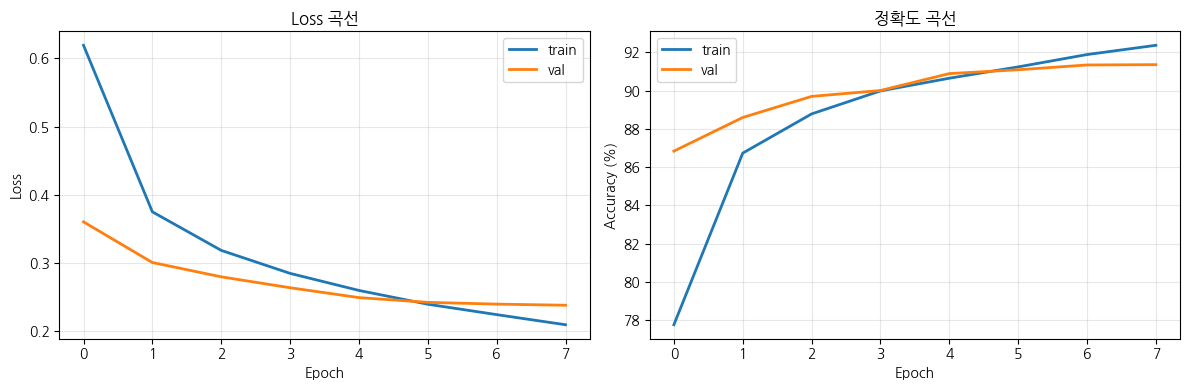


최종 테스트 정확도: 90.4%


In [34]:
# CNN 학습 (T4 GPU 기준 1~2분, CPU는 5~10분)
set_seed(42)
cnn = build_fashion_cnn()

print("CNN 학습 시작...")
history = cnn.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=8,
    batch_size=128,
    verbose=2,   # 1줄씩 진행 출력
)

# 학습 곡선
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'], label='train', linewidth=2)
axes[0].plot(history.history['val_loss'], label='val', linewidth=2)
axes[0].set_title('Loss 곡선'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot([a*100 for a in history.history['accuracy']], label='train', linewidth=2)
axes[1].plot([a*100 for a in history.history['val_accuracy']], label='val', linewidth=2)
axes[1].set_title('정확도 곡선'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

# 테스트 평가
test_loss, test_acc = cnn.evaluate(x_test, y_test, verbose=0)
print(f"\n최종 테스트 정확도: {test_acc:.1%}")

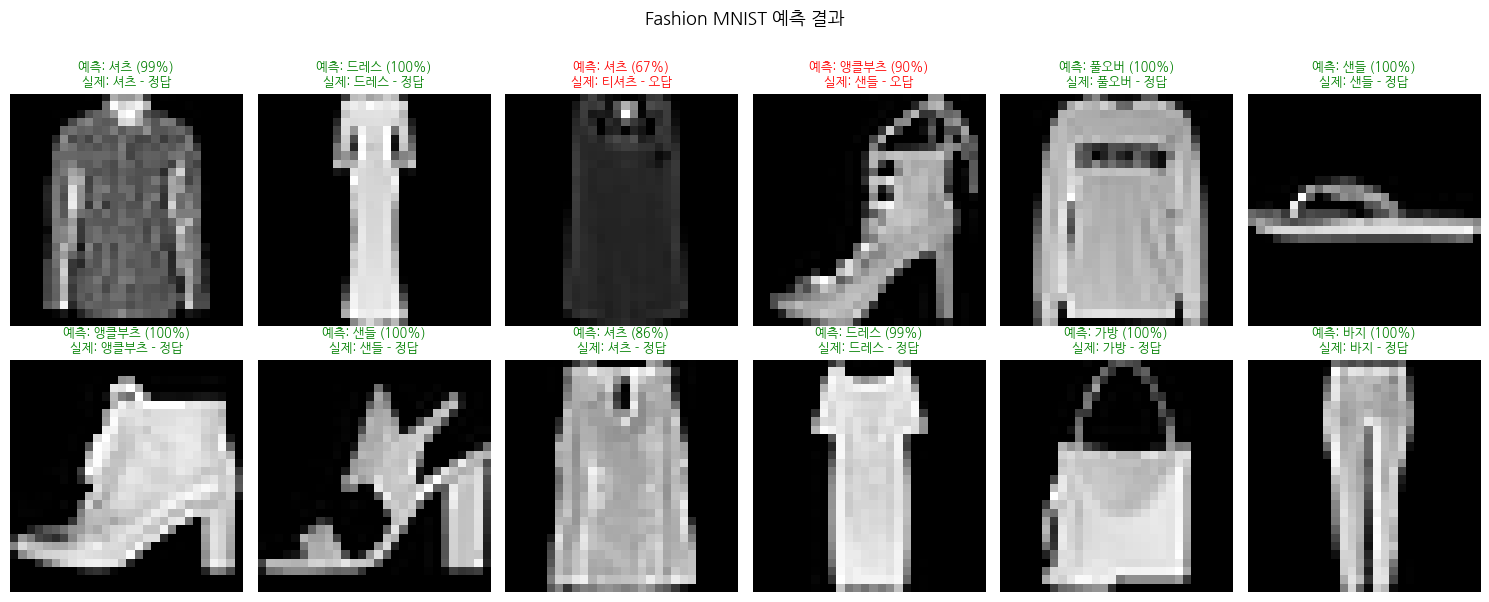

In [35]:
# 예측 결과 시각화
sample_idx = np.random.choice(len(x_test), 12, replace=False)
sample_x = x_test[sample_idx]
sample_y = y_test[sample_idx]

probs = cnn(sample_x).numpy()
preds = probs.argmax(axis=1)

fig, axes = plt.subplots(2, 6, figsize=(15, 6))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(sample_x[i].squeeze(), cmap='gray')
    pred = preds[i]
    true = sample_y[i]
    correct = '정답' if pred == true else '오답'
    color = 'green' if pred == true else 'red'
    ax.set_title(f'예측: {class_names[pred]} ({probs[i, pred]:.0%})\n실제: {class_names[true]} - {correct}',
                  fontsize=9, color=color)
    ax.axis('off')
plt.suptitle('Fashion MNIST 예측 결과', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

## 9. 콜백(Callback) + 모델 저장

### 콜백이란?

> **학습 중 자동으로 발동하는 액션** (체크포인트 저장, 조기 종료, 학습률 조정 등)

PyTorch에서는 EarlyStopping을 직접 만들어야 했지만, **Keras는 미리 만들어진 콜백이 풍부**합니다!

### 자주 쓰는 콜백 3가지

| 콜백 | 역할 |
|---|---|
| `EarlyStopping` | val_loss가 N번 개선 안 되면 학습 중단 |
| `ModelCheckpoint` | 가장 좋은 모델을 자동 저장 |
| `ReduceLROnPlateau` | val_loss가 정체되면 학습률 낮춤 |

### 사용법 - fit()에 callbacks 인자로 전달

```python
callbacks = [
    keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
    keras.callbacks.ModelCheckpoint('best_model.keras', save_best_only=True),
]

model.fit(x, y, epochs=20, callbacks=callbacks)
```

### 모델 저장 포맷

| 포맷 | 확장자 | 특징 |
|---|---|---|
| **`.keras`** (권장) | `.keras` | 모든 정보 (구조 + 가중치 + 옵티마이저) |
| HDF5 (옛날) | `.h5` | 같은 일을 함, 옛 코드와 호환 |
| 가중치만 | `.weights.h5` | 모델 구조는 따로 정의해야 함 |

In [36]:
# EarlyStopping + ModelCheckpoint 적용해서 다시 학습
set_seed(42)
cnn2 = build_fashion_cnn()

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=2,
        restore_best_weights=True,    # 학습 끝날 때 자동으로 best 가중치 복원
        verbose=1,
    ),
    keras.callbacks.ModelCheckpoint(
        'best_fashion_cnn.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1,
    ),
]

print("EarlyStopping + Checkpoint 적용 학습 시작 (최대 15 epoch)...")
history2 = cnn2.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=15,
    batch_size=128,
    callbacks=callbacks,
    verbose=2,
)

# 저장 확인
print(f"\n저장된 모델 파일: {os.path.exists('best_fashion_cnn.keras')}")
print(f"파일 크기: {os.path.getsize('best_fashion_cnn.keras') / 1024:.1f} KB")

# 평가
test_loss, test_acc = cnn2.evaluate(x_test, y_test, verbose=0)
print(f"\n조기 종료 후 테스트 정확도: {test_acc:.1%}")

EarlyStopping + Checkpoint 적용 학습 시작 (최대 15 epoch)...
Epoch 1/15

Epoch 1: val_loss improved from None to 0.35762, saving model to best_fashion_cnn.keras

Epoch 1: finished saving model to best_fashion_cnn.keras
375/375 - 7s - 19ms/step - accuracy: 0.7783 - loss: 0.6185 - val_accuracy: 0.8702 - val_loss: 0.3576
Epoch 2/15

Epoch 2: val_loss improved from 0.35762 to 0.29877, saving model to best_fashion_cnn.keras

Epoch 2: finished saving model to best_fashion_cnn.keras
375/375 - 3s - 7ms/step - accuracy: 0.8683 - loss: 0.3739 - val_accuracy: 0.8885 - val_loss: 0.2988
Epoch 3/15

Epoch 3: val_loss improved from 0.29877 to 0.28248, saving model to best_fashion_cnn.keras

Epoch 3: finished saving model to best_fashion_cnn.keras
375/375 - 2s - 6ms/step - accuracy: 0.8872 - loss: 0.3186 - val_accuracy: 0.8955 - val_loss: 0.2825
Epoch 4/15

Epoch 4: val_loss improved from 0.28248 to 0.26757, saving model to best_fashion_cnn.keras

Epoch 4: finished saving model to best_fashion_cnn.keras
375/3

In [37]:
# 저장된 모델 다시 불러오기 - 한 줄!
loaded_model = keras.models.load_model('best_fashion_cnn.keras')
print("모델 불러오기 성공!")

# 같은 데이터로 평가하면 똑같은 결과
loaded_loss, loaded_acc = loaded_model.evaluate(x_test, y_test, verbose=0)
print(f"불러온 모델 테스트 정확도: {loaded_acc:.1%}  (이전과 동일)")

# 예측도 그대로 가능
sample_pred = loaded_model.predict(x_test[:5], verbose=0)
print(f"\n샘플 예측 shape: {sample_pred.shape}")
print(f"샘플 예측 클래스: {sample_pred.argmax(axis=1)}")
print(f"실제 라벨:       {y_test[:5]}")

모델 불러오기 성공!
불러온 모델 테스트 정확도: 91.0%  (이전과 동일)

샘플 예측 shape: (5, 10)
샘플 예측 클래스: [9 2 1 1 6]
실제 라벨:       [9 2 1 1 6]


## 10. 데이터 증강 (Data Augmentation)

### Keras의 두 가지 방법

#### 방법 1: 모델 안에 증강 레이어 넣기 (권장)
```python
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])
# 모델 첫 부분에 추가
```

#### 방법 2: tf.data 파이프라인으로 변환

이번에는 **방법 1** 을 사용해 봅시다 (더 간단).

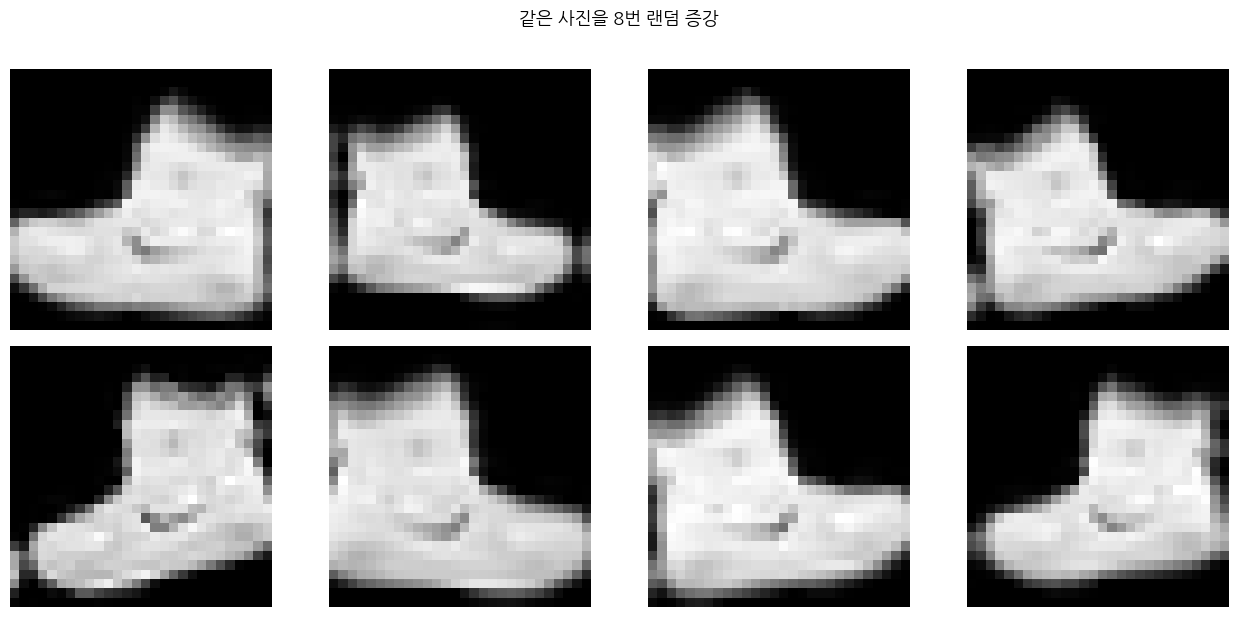

매번 다른 모습이 생성됩니다!
학습 시 매 epoch마다 다른 변형이 적용되어 데이터 다양성이 늘어납니다.


In [38]:
# 증강 레이어 정의
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.05),         # +-5도
    layers.RandomZoom(0.1),              # +-10%
], name='data_augmentation')

# 같은 이미지에 8번 다른 증강 적용
sample_img = x_train[0:1]   # 첫 이미지 (배치 차원 포함)

fig, axes = plt.subplots(2, 4, figsize=(13, 6))
for ax in axes.flatten():
    augmented = data_augmentation(sample_img, training=True)
    ax.imshow(augmented[0].numpy().squeeze(), cmap='gray')
    ax.axis('off')

plt.suptitle('같은 사진을 8번 랜덤 증강', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()
print("매번 다른 모습이 생성됩니다!")
print("학습 시 매 epoch마다 다른 변형이 적용되어 데이터 다양성이 늘어납니다.")

## 11. 전이학습 - CIFAR-10 + MobileNetV2

### 왜 MobileNetV2 ?

PyTorch 노트북에선 ResNet18을 썼지만, 이번엔 **MobileNetV2** 를 사용합니다.
- **모바일에 최적화된 가벼운 모델** (5편에서 본 것)
- TensorFlow Lite 배포의 표준
- ImageNet 사전학습 가중치로 시작

### CIFAR-10의 한 가지 함정

CIFAR-10은 32x32 사이즈인데, **MobileNetV2는 96x96 이상** 을 기대합니다.
-> **Resize 레이어**로 모델 안에서 크기를 키워야 합니다.

CIFAR-10 다운로드 중...
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 141s 1us/step
   train: (50000, 32, 32, 3)
   test:  (10000, 32, 32, 3)

사용할 데이터: train 5,000 / test 1,000


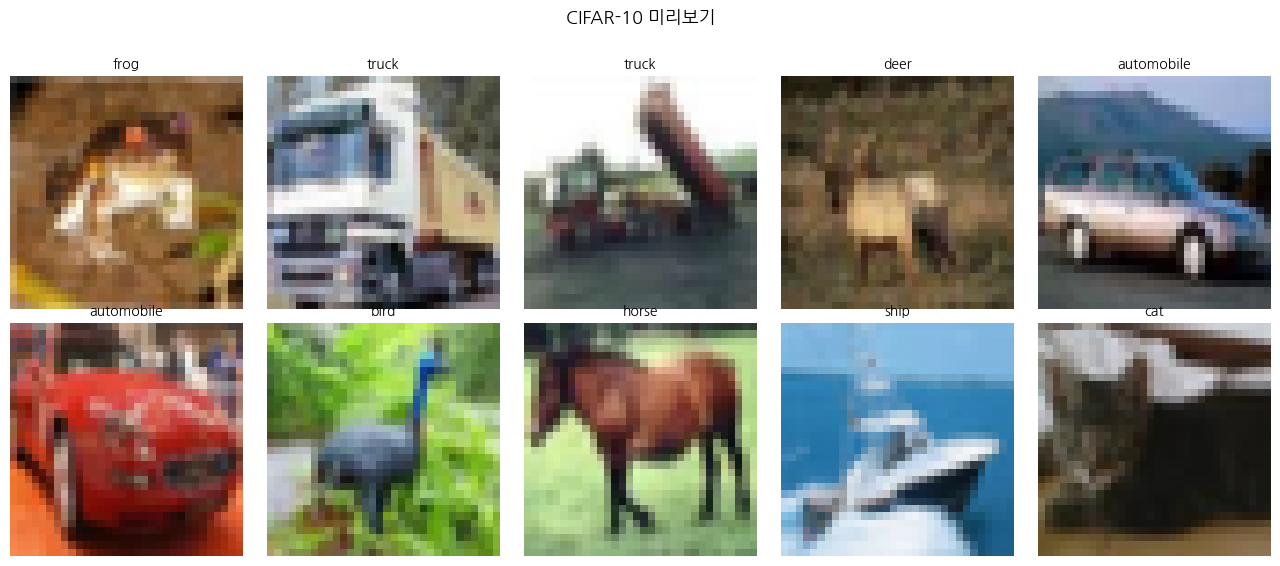

In [39]:
# CIFAR-10 데이터 로드
print("CIFAR-10 다운로드 중...")
(x_train_cifar, y_train_cifar), (x_test_cifar, y_test_cifar) = keras.datasets.cifar10.load_data()
print(f"   train: {x_train_cifar.shape}")
print(f"   test:  {x_test_cifar.shape}")

# 라벨이 (N, 1) 모양이라 (N,) 으로 평탄화
y_train_cifar = y_train_cifar.flatten()
y_test_cifar = y_test_cifar.flatten()

cifar_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                  'dog', 'frog', 'horse', 'ship', 'truck']

# 시간 단축을 위해 일부만 사용
N_TRAIN = 5000
N_TEST = 1000
x_train_small = x_train_cifar[:N_TRAIN].astype(np.float32)
y_train_small = y_train_cifar[:N_TRAIN]
x_test_small = x_test_cifar[:N_TEST].astype(np.float32)
y_test_small = y_test_cifar[:N_TEST]

print(f"\n사용할 데이터: train {len(x_train_small):,} / test {len(x_test_small):,}")

# 미리보기
fig, axes = plt.subplots(2, 5, figsize=(13, 5.5))
for ax, idx in zip(axes.flatten(), range(10)):
    ax.imshow(x_train_small[idx].astype(np.uint8))
    ax.set_title(cifar_classes[y_train_small[idx]], fontsize=10)
    ax.axis('off')
plt.suptitle('CIFAR-10 미리보기', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

---

## 실습 5: MobileNetV2 전이학습 모델 구성

### 만들어야 할 함수
```python
build_transfer_model(num_classes=10)
# 1) MobileNetV2 사전학습 가져오기 (가중치 동결)
# 2) Resize + 전처리 + base_model + 분류 헤드
# 3) Functional API로 조립
```

### 힌트 - 5단계!

```python
# 1) 사전학습 모델 (특징 추출기)
IMG_SIZE = 96
base_model = keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,        # 분류기는 제외 - 우리가 만들 거니까
    weights='imagenet',
)
base_model.trainable = False  # 동결!

# 2) Functional API로 전체 모델 조립
inputs = keras.Input(shape=(32, 32, 3))
x = layers.Resizing(IMG_SIZE, IMG_SIZE)(inputs)              # 32 -> 96
x = keras.applications.mobilenet_v2.preprocess_input(x)      # MobileNet 전처리
x = base_model(x, training=False)                            # 특징 추출
x = layers.GlobalAveragePooling2D()(x)                       # 공간 평균 -> 벡터
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = keras.Model(inputs, outputs)
model.compile(optimizer=keras.optimizers.Adam(1e-3),
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])
return model, base_model
```

### `include_top=False` 가 뭐야?

사전학습 모델의 **마지막 분류기(top)는 빼고** 특징 추출 부분만 가져오기.
1000-class ImageNet 분류기 대신 **우리가 새 분류기를 붙임**!

### `GlobalAveragePooling2D` 는?

(7, 7, 1280) 같은 3D feature map을 (1280,) 벡터로 만듦. 각 채널의 평균!
Flatten보다 파라미터가 훨씬 적어서 과적합에 강합니다.

In [40]:
# 빈칸을 채워서 전이학습 모델을 완성하세요!
def build_transfer_model(num_classes=10):
    IMG_SIZE = 96

    # TODO 1: MobileNetV2 사전학습 모델 가져오기
    base_model = keras.applications.MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet')

    # TODO 2: 가중치 동결
    base_model.trainable = False

    # Functional API로 전체 모델 조립
    inputs = keras.Input(shape=(32, 32, 3))
    x = layers.Resizing(IMG_SIZE, IMG_SIZE)(inputs)
    x = keras.applications.mobilenet_v2.preprocess_input(x)

    # TODO 3: base_model 통과 (training=False 로!)
    x = base_model(x, training=False)   # (힌트: False - BatchNorm 동결을 위해)

    # TODO 4: GlobalAveragePooling 으로 공간 차원 줄이기
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dropout(0.3)(x)

    # TODO 5: 마지막 분류기 (num_classes 출력, softmax)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name='transfer_cifar10')
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])
    return model, base_model

In [41]:
# 자가 검증
try:
    print("MobileNetV2 다운로드 중... (처음엔 약 10MB)")
    transfer_model, base_model = build_transfer_model(num_classes=10)

    # 검증 1) Keras 모델
    is_keras = isinstance(transfer_model, keras.Model)

    # 검증 2) base_model 동결됐는가
    base_frozen = not base_model.trainable

    # 검증 3) 분류 헤드만 학습 가능
    trainable_params = sum(np.prod(v.shape) for v in transfer_model.trainable_variables)
    total_params = transfer_model.count_params()
    # Dense (1280 * 10 + 10 = 12810) 만 학습되어야 함
    trainable_ok = trainable_params == 12810

    # 검증 4) 입력 통과
    test_input = np.random.randn(2, 32, 32, 3).astype(np.float32)
    output = transfer_model(test_input, training=False)
    output_shape_ok = output.shape == (2, 10)

    if is_keras and base_frozen and trainable_ok and output_shape_ok:
        print(f"정답입니다!")
        print(f"\n   전체 파라미터: {total_params:,}")
        print(f"   학습 가능:    {trainable_params:,} (전체의 {trainable_params/total_params*100:.2f}%)")
        print(f"   동결됨:       {total_params - trainable_params:,}")
        print(f"\n   입력 (2, 32, 32, 3) -> 출력 {output.shape}")
        print(f"   MobileNetV2 동결, 분류기만 학습됩니다!")
    else:
        print(f"다시 시도해보세요.")
        print(f"   base_frozen: {base_frozen}")
        print(f"   trainable: {trainable_params} (기대: 12,810)")
        print(f"   output: {output.shape}")
except Exception as e:
    print(f"에러: {e}")

MobileNetV2 다운로드 중... (처음엔 약 10MB)
에러: 'ellipsis' object has no attribute 'trainable'


<details>
<summary>정답 보기 (클릭)</summary>

```python
def build_transfer_model(num_classes=10):
    IMG_SIZE = 96
    base_model = keras.applications.MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights='imagenet',
    )
    base_model.trainable = False

    inputs = keras.Input(shape=(32, 32, 3))
    x = layers.Resizing(IMG_SIZE, IMG_SIZE)(inputs)
    x = keras.applications.mobilenet_v2.preprocess_input(x)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name='transfer_cifar10')
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])
    return model, base_model
```

**해설 - 핵심 포인트**:

1. **`include_top=False`**: 분류기 빼고 특징 추출 부분만
2. **`base_model.trainable = False`**: 가중치 동결
3. **`base_model(x, training=False)`**: BatchNorm 통계도 동결 (중요!)
4. **`GlobalAveragePooling2D`**: 공간 평균으로 벡터화 (Flatten보다 안정적)
5. **`mobilenet_v2.preprocess_input`**: MobileNet이 학습된 그 정규화를 그대로 적용

> training=False 가 왜 중요? base_model에 BatchNorm 레이어가 많은데,
> training=True 면 학습 모드로 동작해서 통계를 업데이트하려 합니다 (동결의 의미가 무색해짐).

</details>

In [42]:
# 표준 정답 함수
def build_transfer_model(num_classes=10):
    IMG_SIZE = 96
    base_model = keras.applications.MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False, weights='imagenet')
    base_model.trainable = False

    inputs = keras.Input(shape=(32, 32, 3))
    x = layers.Resizing(IMG_SIZE, IMG_SIZE)(inputs)
    x = keras.applications.mobilenet_v2.preprocess_input(x)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name='transfer_cifar10')
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])
    return model, base_model

print("build_transfer_model 준비 완료!")

build_transfer_model 준비 완료!


### 실습 5 보강: 전이학습 모델 들여다보기

MobileNetV2 전이학습 모델이 어떻게 구성되는지 시각적으로 살펴봅시다.
- 어느 부분이 동결되었나?
- 학습 가능 vs 동결 파라미터 비율
- ImageNet 사전학습된 첫 conv 필터 모양

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


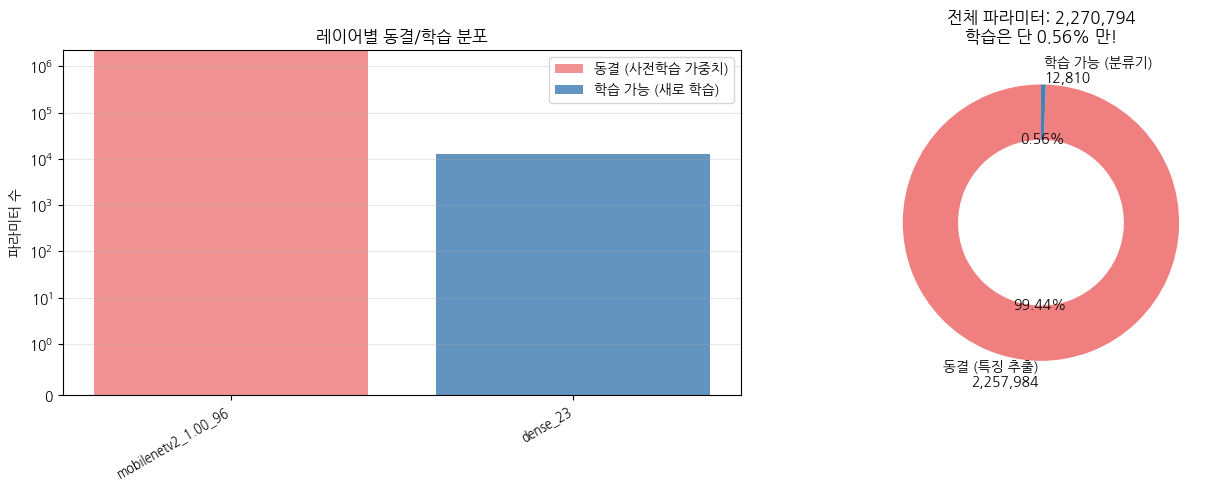

전체 파라미터:    2,270,794
   동결 (사전학습): 2,257,984 (99.44%)
   학습 가능 (분류기): 12,810 (0.56%)

전이학습의 마법: 1% 미만의 파라미터만 학습해도 좋은 성능!


In [43]:
# 시각화 1: 동결 vs 학습 가능 파라미터 분포
transfer_check, base_check = build_transfer_model(num_classes=10)

# 학습 가능 / 동결 파라미터 수 계산
trainable_count = int(sum(np.prod(v.shape) for v in transfer_check.trainable_variables))
total_count = int(transfer_check.count_params())
frozen_count = total_count - trainable_count

# 시각화: 막대 + 파이 두 가지 시점
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (좌) 레이어별 파라미터 (top-level 레이어)
layer_info = []
for layer in transfer_check.layers:
    n_total = layer.count_params()
    if hasattr(layer, 'trainable') and layer.trainable:
        n_trainable = int(sum(np.prod(v.shape) for v in layer.trainable_variables))
    else:
        n_trainable = 0
    n_frozen = n_total - n_trainable
    layer_info.append({
        'name': layer.name,
        'total': n_total,
        'trainable': n_trainable,
        'frozen': n_frozen,
    })

# 파라미터가 있는 레이어만 표시
visible = [info for info in layer_info if info['total'] > 0]
names = [info['name'] for info in visible]
frozen = [info['frozen'] for info in visible]
trainable = [info['trainable'] for info in visible]

x = range(len(names))
axes[0].bar(x, frozen, label='동결 (사전학습 가중치)', color='lightcoral', alpha=0.85)
axes[0].bar(x, trainable, bottom=frozen, label='학습 가능 (새로 학습)', color='steelblue', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(names, rotation=30, ha='right', fontsize=9)
axes[0].set_ylabel('파라미터 수')
axes[0].set_title('레이어별 동결/학습 분포')
axes[0].legend(); axes[0].grid(alpha=0.3, axis='y')
axes[0].set_yscale('symlog', linthresh=1)

# (우) 전체 비율 파이차트
sizes = [frozen_count, trainable_count]
labels = [f'동결 (특징 추출)\n{frozen_count:,}', f'학습 가능 (분류기)\n{trainable_count:,}']
colors_pie = ['lightcoral', 'steelblue']
axes[1].pie(sizes, labels=labels, colors=colors_pie, autopct='%1.2f%%',
             startangle=90, wedgeprops=dict(width=0.4))
axes[1].set_title(f'전체 파라미터: {total_count:,}\n학습은 단 {trainable_count/total_count*100:.2f}% 만!')

plt.tight_layout(); plt.show()

print(f"전체 파라미터:    {total_count:,}")
print(f"   동결 (사전학습): {frozen_count:,} ({frozen_count/total_count*100:.2f}%)")
print(f"   학습 가능 (분류기): {trainable_count:,} ({trainable_count/total_count*100:.2f}%)")
print(f"\n전이학습의 마법: 1% 미만의 파라미터만 학습해도 좋은 성능!")

=== training 인자에 따른 출력 차이 ===

학습 모드 (training=True): Dropout이 매번 다르게 동작
   1회차: [0.14566682 0.0971619  0.11631515 0.1396782  0.02642578]
   2회차: [0.11991246 0.01799936 0.7310213  0.00246377 0.00774747]
   같은가? False

추론 모드 (training=False): 항상 같은 결과
   1회차: [0.07252559 0.04947007 0.24635813 0.0522286  0.0510724 ]
   2회차: [0.07252559 0.04947007 0.24635813 0.0522286  0.0510724 ]
   같은가? True


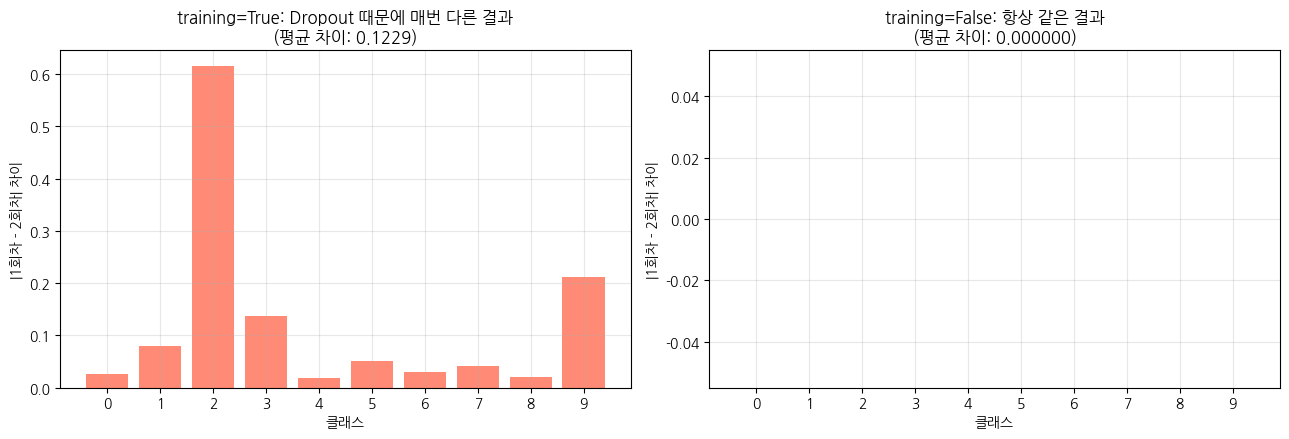


실무 팁:
- 추론(예측) 시: 반드시 training=False (또는 model.predict())
- 학습 시: training=True (또는 model.fit())
- model() 직접 호출 시 기본값은 None → training=False처럼 동작 (안전)


In [44]:
# 시각화 2: training=False vs True - BatchNorm의 차이
# 같은 모델에 같은 입력을 넣어도 training 인자에 따라 결과가 다름

# 가짜 CIFAR 사이즈 입력
test_x = np.random.randn(2, 32, 32, 3).astype(np.float32)

# Dropout이 있어 같은 입력이 다른 결과 (학습 모드)
out_train_1 = transfer_check(test_x, training=True).numpy()
out_train_2 = transfer_check(test_x, training=True).numpy()

# 추론 모드 - 항상 같은 결과
out_eval_1 = transfer_check(test_x, training=False).numpy()
out_eval_2 = transfer_check(test_x, training=False).numpy()

print("=== training 인자에 따른 출력 차이 ===\n")
print("학습 모드 (training=True): Dropout이 매번 다르게 동작")
print(f"   1회차: {out_train_1[0][:5]}")
print(f"   2회차: {out_train_2[0][:5]}")
print(f"   같은가? {np.allclose(out_train_1, out_train_2)}")

print("\n추론 모드 (training=False): 항상 같은 결과")
print(f"   1회차: {out_eval_1[0][:5]}")
print(f"   2회차: {out_eval_2[0][:5]}")
print(f"   같은가? {np.allclose(out_eval_1, out_eval_2)}")

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# 학습 모드 - Dropout으로 인한 변화
diff_train = np.abs(out_train_1 - out_train_2)[0]
axes[0].bar(range(10), diff_train, color='tomato', alpha=0.75)
axes[0].set_xlabel('클래스')
axes[0].set_ylabel('|1회차 - 2회차| 차이')
axes[0].set_title(f'training=True: Dropout 때문에 매번 다른 결과\n(평균 차이: {diff_train.mean():.4f})')
axes[0].set_xticks(range(10))
axes[0].grid(alpha=0.3)

# 추론 모드 - 항상 동일
diff_eval = np.abs(out_eval_1 - out_eval_2)[0]
axes[1].bar(range(10), diff_eval, color='seagreen', alpha=0.75)
axes[1].set_xlabel('클래스')
axes[1].set_ylabel('|1회차 - 2회차| 차이')
axes[1].set_title(f'training=False: 항상 같은 결과\n(평균 차이: {diff_eval.mean():.6f})')
axes[1].set_xticks(range(10))
axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

print("\n실무 팁:")
print("- 추론(예측) 시: 반드시 training=False (또는 model.predict())")
print("- 학습 시: training=True (또는 model.fit())")
print("- model() 직접 호출 시 기본값은 None → training=False처럼 동작 (안전)")

### 실습 5 추가 테스트: 전이학습 모델 검증

다양한 케이스로 모델이 제대로 만들어졌는지 확인합니다.

In [45]:
# 추가 테스트: 5가지 케이스
print("=== 실습 5 종합 테스트 ===\n")
tests_passed = 0

# 테스트 1: base_model이 동결됐는가
test1 = not base_check.trainable
print(f"[테스트 1] base_model 동결됨: {'OK' if test1 else 'FAIL'}")
tests_passed += int(test1)

# 테스트 2: 컴파일 됐는가
test2 = transfer_check.optimizer is not None
print(f"[테스트 2] 모델 컴파일 됨: {'OK' if test2 else 'FAIL'}")
tests_passed += int(test2)

# 테스트 3: 다양한 배치 크기
test3 = True
for bs in [1, 4, 32]:
    try:
        test_x_bs = np.random.randn(bs, 32, 32, 3).astype(np.float32)
        out = transfer_check(test_x_bs, training=False)
        if out.shape != (bs, 10):
            test3 = False; break
    except:
        test3 = False; break
print(f"[테스트 3] 배치 크기 1, 4, 32 통과: {'OK' if test3 else 'FAIL'}")
tests_passed += int(test3)

# 테스트 4: softmax 출력 합 = 1
test_x4 = np.random.randn(4, 32, 32, 3).astype(np.float32)
out4 = transfer_check(test_x4, training=False).numpy()
sums = np.sum(out4, axis=1)
test4 = np.allclose(sums, 1.0, atol=1e-5)
print(f"[테스트 4] softmax 출력 합 = 1: {'OK' if test4 else 'FAIL'} (합: {np.round(sums, 4)})")
tests_passed += int(test4)

# 테스트 5: 학습 가능 파라미터가 마지막 분류기뿐인가
trainable_p = sum(np.prod(v.shape) for v in transfer_check.trainable_variables)
# Dense(num_classes=10): 1280 * 10 + 10 = 12810
expected = 12810
test5 = trainable_p == expected
print(f"[테스트 5] 학습 가능 파라미터 = {expected:,}: {'OK' if test5 else 'FAIL'} (실제: {trainable_p:,})")
tests_passed += int(test5)

print(f"\n전체: {tests_passed}/5 통과")
if tests_passed == 5:
    print("모든 테스트 통과! 전이학습 모델이 제대로 구성되었습니다.")

=== 실습 5 종합 테스트 ===

[테스트 1] base_model 동결됨: OK
[테스트 2] 모델 컴파일 됨: OK
[테스트 3] 배치 크기 1, 4, 32 통과: OK
[테스트 4] softmax 출력 합 = 1: OK (합: [1. 1. 1. 1.])
[테스트 5] 학습 가능 파라미터 = 12,810: OK (실제: 12,810)

전체: 5/5 통과
모든 테스트 통과! 전이학습 모델이 제대로 구성되었습니다.


### 1단계: 분류기만 학습

In [46]:
# 전이학습 1단계 - 분류 헤드만 학습
set_seed(42)
transfer_model, base_model = build_transfer_model(num_classes=10)

print("1단계 - 분류기만 학습 (3 epoch)...")
hist1 = transfer_model.fit(
    x_train_small, y_train_small,
    validation_data=(x_test_small, y_test_small),
    epochs=3,
    batch_size=64,
    verbose=2,
)

print(f"\n1단계 후 테스트 정확도: {hist1.history['val_accuracy'][-1]:.1%}")

1단계 - 분류기만 학습 (3 epoch)...
Epoch 1/3
79/79 - 45s - 576ms/step - accuracy: 0.5312 - loss: 1.4313 - val_accuracy: 0.7780 - val_loss: 0.6691
Epoch 2/3
79/79 - 1s - 16ms/step - accuracy: 0.7642 - loss: 0.6966 - val_accuracy: 0.8120 - val_loss: 0.5475
Epoch 3/3
79/79 - 1s - 15ms/step - accuracy: 0.8136 - loss: 0.5547 - val_accuracy: 0.8330 - val_loss: 0.5025

1단계 후 테스트 정확도: 83.3%


### 2단계: Fine-tuning (base_model 일부 풀기)

PyTorch에서는 `for name, p:` 로 직접 풀었지만, Keras는 더 간단합니다.

2단계 - Fine-tuning (base_model 끝 부분 풀기)...
   학습 가능 파라미터: 1,539,210 / 전체 2,270,794 (67.8%)
Epoch 1/3
79/79 - 34s - 433ms/step - accuracy: 0.7188 - loss: 0.8568 - val_accuracy: 0.8340 - val_loss: 0.5211
Epoch 2/3
79/79 - 2s - 20ms/step - accuracy: 0.8002 - loss: 0.6035 - val_accuracy: 0.8290 - val_loss: 0.5384
Epoch 3/3
79/79 - 2s - 19ms/step - accuracy: 0.8326 - loss: 0.5124 - val_accuracy: 0.8300 - val_loss: 0.5408


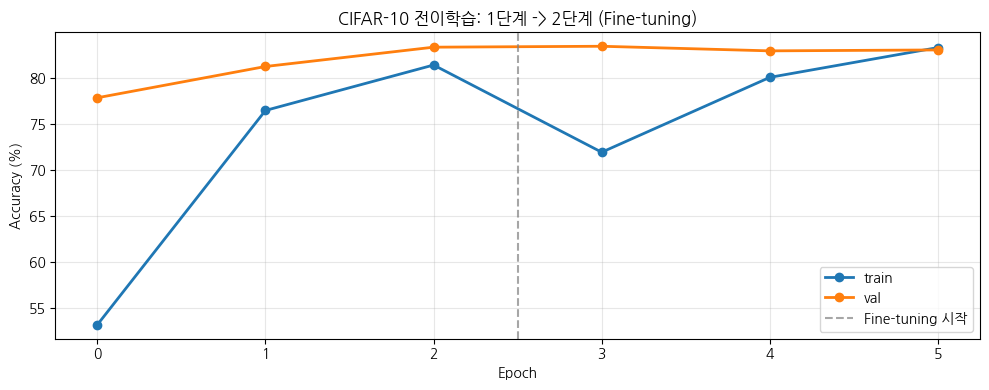


최종 정확도: 83.0%
적은 데이터(5000장)로도 좋은 결과 - 사전학습의 힘!


In [47]:
# 전이학습 2단계 - Fine-tuning
print("2단계 - Fine-tuning (base_model 끝 부분 풀기)...")

# base_model 의 끝 부분 일부만 학습 가능하게 풀기
base_model.trainable = True
# 전체 154개 layer 중 마지막 30개만 풀기
fine_tune_at = len(base_model.layers) - 30
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# 더 작은 학습률로 재컴파일 (강하게 안 건드리려고)
transfer_model.compile(
    optimizer=keras.optimizers.Adam(1e-5),     # 1단계의 1/100
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

trainable = sum(np.prod(v.shape) for v in transfer_model.trainable_variables)
total = transfer_model.count_params()
print(f"   학습 가능 파라미터: {trainable:,} / 전체 {total:,} ({trainable/total*100:.1f}%)")

hist2 = transfer_model.fit(
    x_train_small, y_train_small,
    validation_data=(x_test_small, y_test_small),
    epochs=3,
    batch_size=64,
    verbose=2,
)

# 두 단계 학습 곡선 합치기
all_acc = hist1.history['accuracy'] + hist2.history['accuracy']
all_val_acc = hist1.history['val_accuracy'] + hist2.history['val_accuracy']

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot([a*100 for a in all_acc], 'o-', label='train', linewidth=2)
ax.plot([a*100 for a in all_val_acc], 'o-', label='val', linewidth=2)
ax.axvline(x=2.5, color='gray', linestyle='--', alpha=0.7, label='Fine-tuning 시작')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)')
ax.set_title('CIFAR-10 전이학습: 1단계 -> 2단계 (Fine-tuning)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

final_acc = hist2.history['val_accuracy'][-1]
print(f"\n최종 정확도: {final_acc:.1%}")
print(f"적은 데이터(5000장)로도 좋은 결과 - 사전학습의 힘!")

### 테스트 데이터 예측

테스트 데이터 예측 중...
테스트 데이터 1000장 전체 정확도: 83.0%



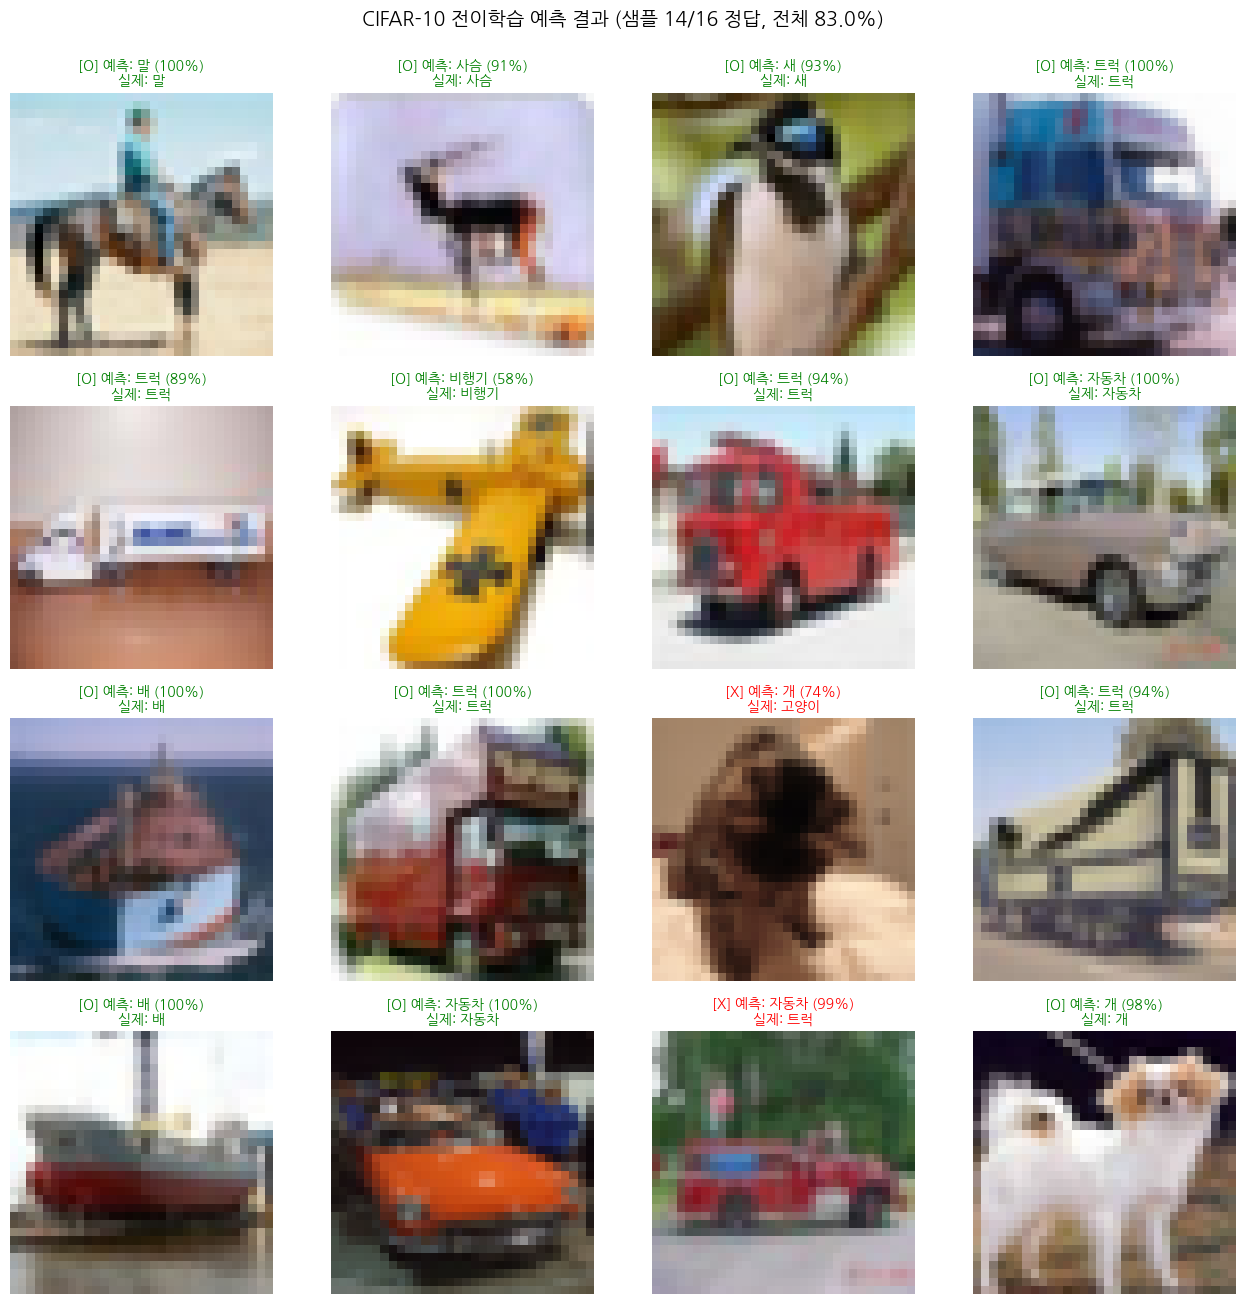

In [48]:
# CIFAR-10 전이학습 모델 예측 시각화 (Keras 버전)
import numpy as np
import matplotlib.pyplot as plt

# CIFAR-10 클래스 이름 (한글)
cifar_class_names_kr = ['비행기', '자동차', '새', '고양이', '사슴',
                         '개', '개구리', '말', '배', '트럭']

# 1) 전체 테스트 데이터 예측 (Keras의 model.predict 한 줄!)
print("테스트 데이터 예측 중...")
predictions = transfer_model.predict(x_test_small, batch_size=64, verbose=0)
pred_classes = predictions.argmax(axis=1)
pred_probs = predictions.max(axis=1)

# 전체 정확도
overall_acc = np.mean(pred_classes == y_test_small)
print(f"테스트 데이터 {len(x_test_small)}장 전체 정확도: {overall_acc:.1%}\n")

# 2) 랜덤 16장 시각화 (4x4 그리드)
np.random.seed(42)
N_SHOW = 16
indices = np.random.choice(len(x_test_small), N_SHOW, replace=False)

fig, axes = plt.subplots(4, 4, figsize=(13, 13))
correct_count = 0
for i, ax in enumerate(axes.flatten()):
    idx = indices[i]
    img = x_test_small[idx]

    # 데이터가 0~255 범위면 uint8로, 0~1 범위면 그대로 (안전 처리)
    img_show = img.astype(np.uint8) if img.max() > 1.5 else img

    true_idx = int(y_test_small[idx])
    pred_idx = int(pred_classes[idx])
    prob = float(pred_probs[idx])

    is_correct = (pred_idx == true_idx)
    if is_correct:
        correct_count += 1

    ax.imshow(img_show)
    ax.axis('off')

    color = 'green' if is_correct else 'red'
    mark = 'O' if is_correct else 'X'
    title = (f'[{mark}] 예측: {cifar_class_names_kr[pred_idx]} ({prob:.0%})\n'
              f'실제: {cifar_class_names_kr[true_idx]}')
    ax.set_title(title, fontsize=10, color=color)

plt.suptitle(f'CIFAR-10 전이학습 예측 결과 '
              f'(샘플 {correct_count}/{N_SHOW} 정답, 전체 {overall_acc:.1%})',
              fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

### 오답 케이스

오답 개수: 170/1000


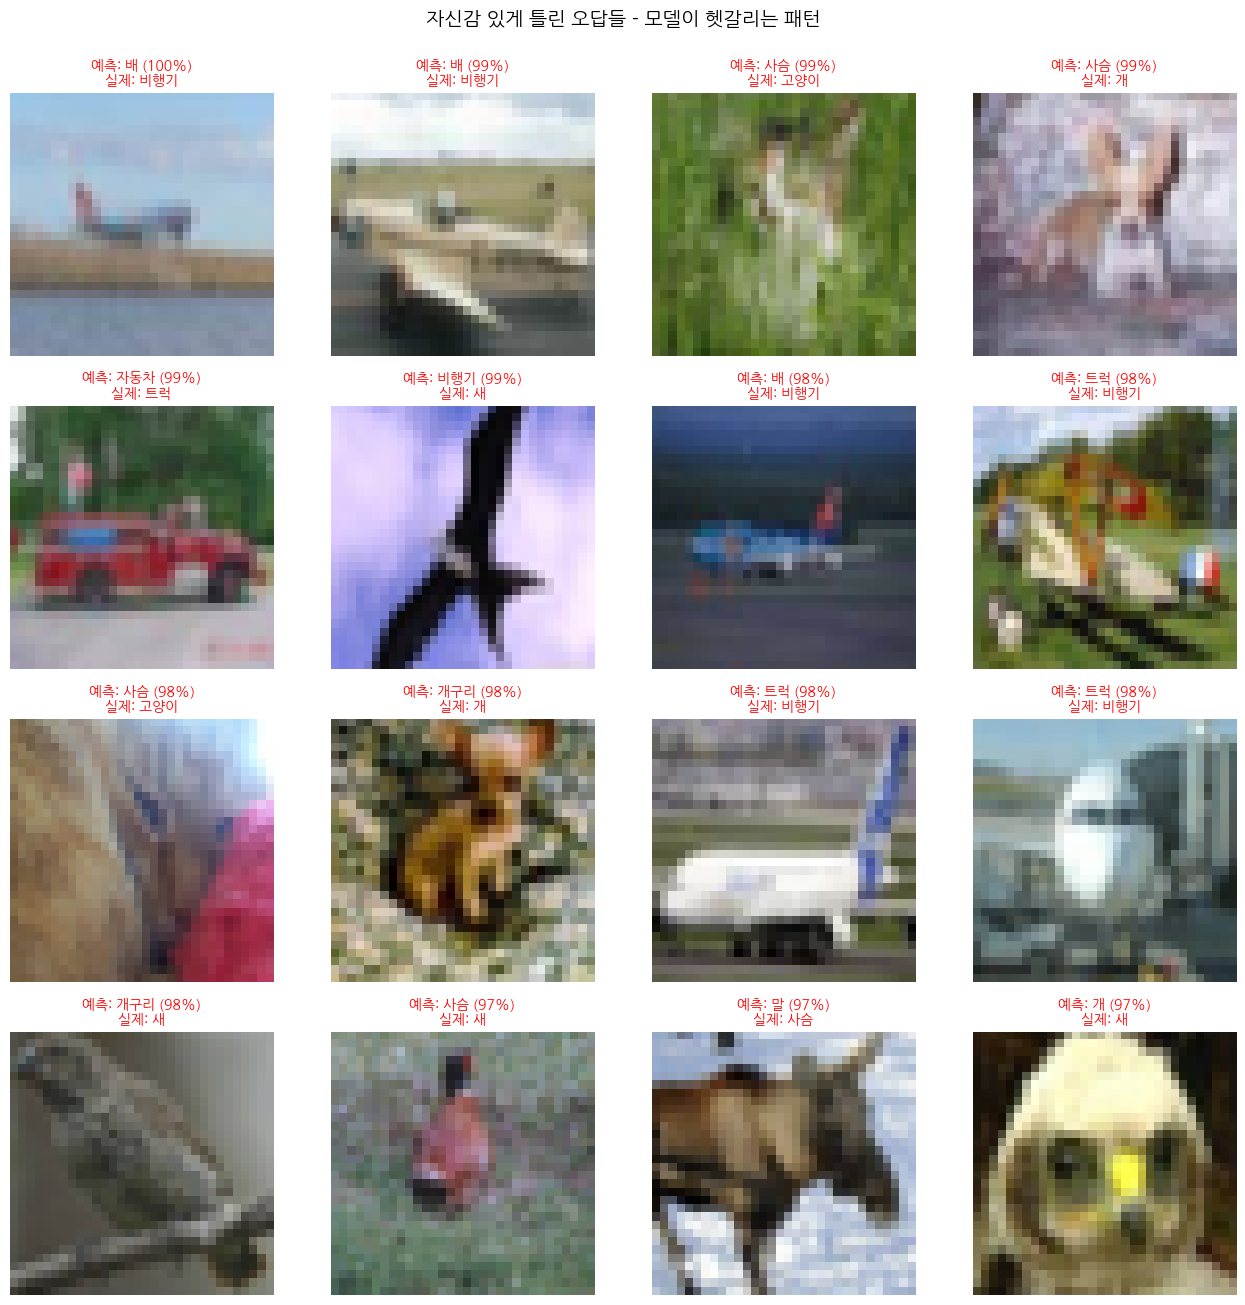

In [49]:
# 오답만 모아서 보기 - 모델의 약점 파악
wrong_mask = (pred_classes != y_test_small)
wrong_indices = np.where(wrong_mask)[0]
print(f"오답 개수: {len(wrong_indices)}/{len(x_test_small)}")

if len(wrong_indices) > 0:
    # 확률이 가장 높았던 (자신감 있게 틀린) 오답 16장
    wrong_probs = pred_probs[wrong_indices]
    confident_wrong = wrong_indices[np.argsort(-wrong_probs)[:16]]

    fig, axes = plt.subplots(4, 4, figsize=(13, 13))
    for i, ax in enumerate(axes.flatten()):
        if i >= len(confident_wrong):
            ax.axis('off'); continue
        idx = confident_wrong[i]
        img = x_test_small[idx]
        img_show = img.astype(np.uint8) if img.max() > 1.5 else img

        true_idx = int(y_test_small[idx])
        pred_idx = int(pred_classes[idx])
        prob = float(pred_probs[idx])

        ax.imshow(img_show)
        ax.set_title(f'예측: {cifar_class_names_kr[pred_idx]} ({prob:.0%})\n'
                      f'실제: {cifar_class_names_kr[true_idx]}',
                      fontsize=10, color='red')
        ax.axis('off')

    plt.suptitle('자신감 있게 틀린 오답들 - 모델이 헷갈리는 패턴', fontsize=14, y=1.00)
    plt.tight_layout(); plt.show()
else:
    print("모두 정답! (테스트 샘플이 작아서일 수 있음)")

### 혼잡 행렬로 클래스별 정확도 비교

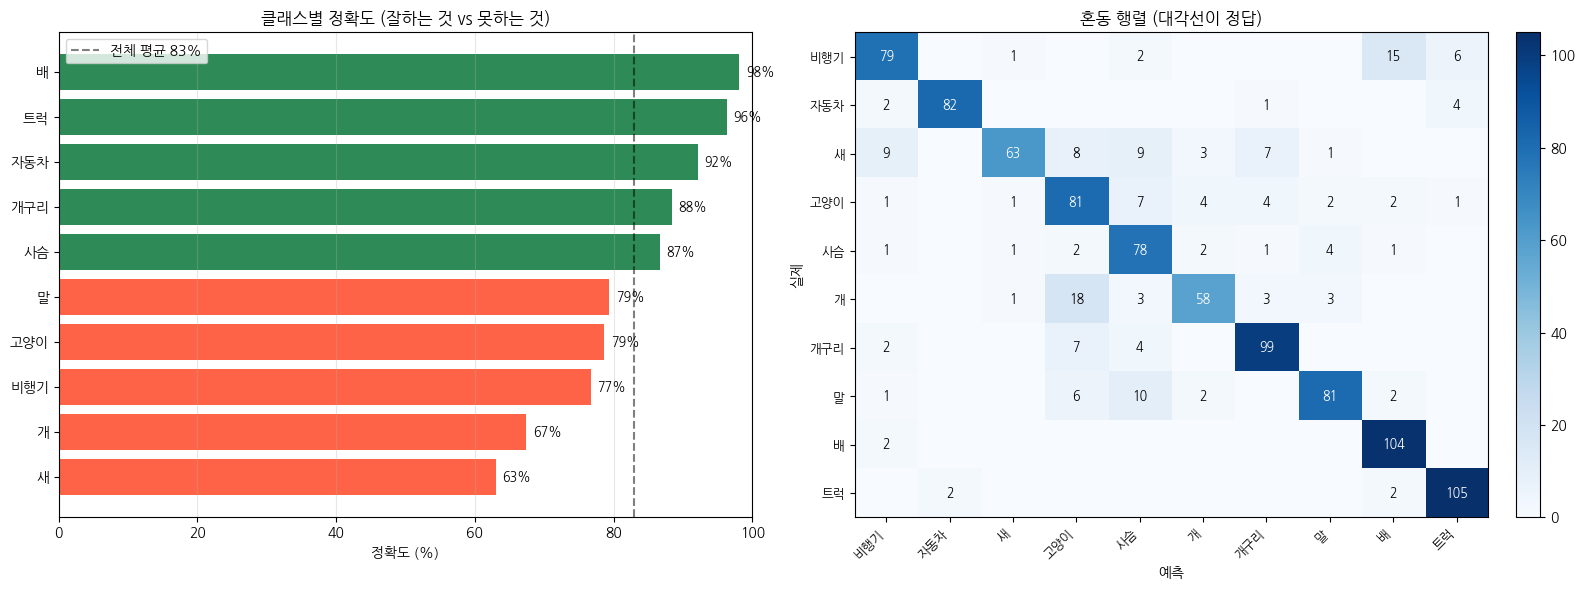


=== 모델이 가장 자주 헷갈리는 쌍 (Top 5) ===
   '개' 를 '고양이' 로 오인 -> 18회
   '비행기' 를 '배' 로 오인 -> 15회
   '말' 를 '사슴' 로 오인 -> 10회
   '새' 를 '사슴' 로 오인 -> 9회
   '새' 를 '비행기' 로 오인 -> 9회


In [50]:
# 클래스별 정확도 분석
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# (좌) 클래스별 정확도 막대
class_correct = np.zeros(10)
class_total = np.zeros(10)
for true, pred in zip(y_test_small, pred_classes):
    class_total[true] += 1
    if true == pred:
        class_correct[true] += 1

class_acc = np.where(class_total > 0, class_correct / class_total, 0)
sorted_idx = np.argsort(-class_acc)   # 정확도 높은 순으로 정렬
sorted_names = [cifar_class_names_kr[i] for i in sorted_idx]
sorted_acc = class_acc[sorted_idx]

bars = axes[0].barh(range(10), sorted_acc * 100,
                      color=['seagreen' if a >= overall_acc else 'tomato'
                              for a in sorted_acc])
axes[0].set_yticks(range(10))
axes[0].set_yticklabels(sorted_names)
axes[0].invert_yaxis()
axes[0].axvline(overall_acc * 100, color='black', linestyle='--', alpha=0.5,
                 label=f'전체 평균 {overall_acc:.0%}')
axes[0].set_xlabel('정확도 (%)')
axes[0].set_title('클래스별 정확도 (잘하는 것 vs 못하는 것)')
axes[0].set_xlim(0, 100)
axes[0].legend()
axes[0].grid(alpha=0.3, axis='x')
for i, (bar, a) in enumerate(zip(bars, sorted_acc)):
    axes[0].text(a * 100 + 1, i, f'{a:.0%}', va='center', fontsize=9)

# (우) 혼동 행렬 (Confusion Matrix)
cm = np.zeros((10, 10), dtype=int)
for true, pred in zip(y_test_small, pred_classes):
    cm[int(true), int(pred)] += 1

im = axes[1].imshow(cm, cmap='Blues', aspect='auto')
axes[1].set_xticks(range(10))
axes[1].set_yticks(range(10))
axes[1].set_xticklabels(cifar_class_names_kr, rotation=45, ha='right', fontsize=9)
axes[1].set_yticklabels(cifar_class_names_kr, fontsize=9)
axes[1].set_xlabel('예측')
axes[1].set_ylabel('실제')
axes[1].set_title('혼동 행렬 (대각선이 정답)')

# 셀에 숫자 표시
for i in range(10):
    for j in range(10):
        if cm[i, j] > 0:
            color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
            axes[1].text(j, i, str(cm[i, j]), ha='center', va='center',
                          color=color, fontsize=9)

plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()

# 가장 자주 헷갈리는 클래스 쌍 출력
print("\n=== 모델이 가장 자주 헷갈리는 쌍 (Top 5) ===")
mistakes = []
for i in range(10):
    for j in range(10):
        if i != j and cm[i, j] > 0:
            mistakes.append((cm[i, j], i, j))
mistakes.sort(reverse=True)
for count, i, j in mistakes[:5]:
    print(f"   '{cifar_class_names_kr[i]}' 를 '{cifar_class_names_kr[j]}' 로 오인 -> {count}회")

## 12. 한 장으로 정리

### 오늘 직접 만든 것 5가지

1. **`numpy_to_tf_2d`** - NumPy <-> tf 텐서 변환
2. **GradientTape 학습 루프** - TF의 자동 미분 직접 사용
3. **`build_housing_regressor`** - Sequential API 회귀 모델
4. **`build_fashion_cnn`** - Functional API CNN
5. **`build_transfer_model`** - MobileNetV2 전이학습

### TensorFlow / Keras 핵심 패턴

#### 모델 정의 (3가지 방식)

```python
# 1. Sequential - 가장 간단 (일렬로만 쌓을 때)
model = keras.Sequential([
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax'),
])

# 2. Functional - 복잡한 구조 (갈라지고 합치는 그래프)
inputs = keras.Input(shape=(8,))
x = layers.Dense(64, activation='relu')(inputs)
outputs = layers.Dense(10, activation='softmax')(x)
model = keras.Model(inputs, outputs)

# 3. Subclass - PyTorch 스타일 (가장 자유로움)
class MyModel(keras.Model):
    def __init__(self): ...
    def call(self, x): ...
```

#### 학습 (Keras 매직)

```python
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
history = model.fit(x, y, validation_data=(x_v, y_v), epochs=10,
                     callbacks=[keras.callbacks.EarlyStopping(patience=3)])
loss, metric = model.evaluate(x_test, y_test)
preds = model.predict(x_new)
```

### PyTorch vs TensorFlow 핵심 차이

| | PyTorch | TensorFlow / Keras |
|---|---|---|
| 모델 정의 | `class(nn.Module)` 위주 | Sequential/Functional 위주 |
| 학습 루프 | for문 직접 작성 | `model.fit()` 한 줄 |
| 자동 미분 | `requires_grad=True` + `.backward()` | `tf.GradientTape` |
| 채널 위치 | `(N, C, H, W)` | `(N, H, W, C)` |
| 학습 모드 | `.train()/.eval()` 명시 | `training=True/False` 자동 |
| 가중치 변수 | `nn.Parameter` (자동) | `tf.Variable` (명시) |
| 모델 저장 | `torch.save(state_dict)` | `model.save('m.keras')` |

### 작업별 손실 함수 (Keras)

| 작업 | loss | 마지막 활성화 |
|---|---|---|
| 회귀 | `'mse'` | 없음 |
| 이진 분류 | `'binary_crossentropy'` | `'sigmoid'` |
| 다중 분류 (정수 라벨) | `'sparse_categorical_crossentropy'` | `'softmax'` |
| 다중 분류 (원핫 라벨) | `'categorical_crossentropy'` | `'softmax'` |

### 다음 단계 추천

- **TensorFlow Lite**: 모바일 앱에 모델 배포
- **TensorFlow Serving**: 프로덕션 서버 배포
- **Keras Tuner**: 하이퍼파라미터 자동 탐색
- **TF Datasets**: 다양한 데이터셋 한 줄로 로드
- **Hugging Face Transformers**: TF/PyTorch 둘 다 지원

### 결국...

**PyTorch를 알면 TF도 80% 이해됩니다.** 두 프레임워크의 철학과 코드 스타일은 다르지만,
**해결하는 문제는 정확히 같기 때문**이죠. 같은 산을 다른 길로 오르는 셈입니다.

---

> **수고하셨습니다!**
>
> 이제 TensorFlow / Keras로 텐서를 다루고, Sequential/Functional 모델을 만들고,
> `compile + fit` 으로 학습시키고, 사전학습 모델을 가져다 자기 데이터에 맞게 변형할 수 있습니다.
>
> 5개의 실습을 모두 통과한 여러분, 정말 대단합니다!
> PyTorch 노트북과 함께 봤다면, 이제 어떤 딥러닝 프로젝트를 보더라도
> 코드를 읽고 이해할 수 있는 사람이 되었어요.